# ETS MARL — Data Science Analysis

Implements the analyses described in `planning/data_science_analysis_plan.md`
(v3). Every section ties back to a specific thesis claim. The structure is:

| § | Analysis | Claim | Methods |
|---|---|---|---|
| C1 | Convergence | RQ1.a | Rolling-mean plateau + PELT change-point |
| C2 | Cross-seed reproducibility | RQ1.b | Fan charts + cross-seed CV |
| S1 | Strategy archetypes | RQ3.a | KMeans + hierarchical + PCA |
| S2 | Reward-weight effect on strategy | RQ3.b | S1 pipeline applied to all-financial variant; centroid contrast |
| S3 | Economic rationality of strategies | RQ3.c | LASSO logit + Random Forest + anchor-vs-realised price |
| R1 | Regulatory shifts | RQ2.a | Cluster shift in shared PCA space + outcome boxplots (IQR) |
| R2 | UDBC compliance pathways | RQ2.b | Multinomial logit + RF + SMOTE; transition heatmaps |

**Data ingestion.** Mirrors `notebooks/ets_marl - Default RQ Analysis.ipynb`
and `notebooks/ets_marl - Sweep Analysis.ipynb`: load one or more sweep specs,
expand each variant's overrides over the base config, then walk
`<output_dir>/<variant>/` for `training_log_*.csv` (per episode) and
`year_log_*.csv` (per year). All runs are keyed by `(sweep, variant, seed)`.

**Robustness.** Every section guards against missing data — sections that
need a non-default variant (S2 cross-variant, R1, R2 cross-variant) skip
gracefully when only default seeds are loaded. This means the notebook
runs end-to-end on the smoke dataset
(`configs/sweeps/smoke_ds_analysis.yaml`) and on the full sweep without
edits.

**Methodology.** Standardisation before any distance-based method (KMeans,
PCA, LASSO). Train/val splits or cross-validation for any predictive model.
Multi-method robustness on every headline claim — see the table in the
planning doc §7.


In [1]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True (or run the cell with required packages missing)
# to pip-install everything in notebooks/requirements-notebooks.txt using the
# CURRENT kernel's interpreter. This is more reliable than `%pip install -r {path}`
# (IPython magics don't expand `{var}` at runtime) and works on Azure / Colab / local.
import subprocess, sys, importlib, re
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False  # flip to True to force-reinstall

# Map PyPI distribution name -> import module name when they differ.
_DIST_TO_IMPORT = {
    "pyyaml": "yaml",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "opencv-python": "cv2",
    "pillow": "PIL",
    "beautifulsoup4": "bs4",
    "ipython": "IPython",
}

def _find_requirements():
    req_name = "requirements-notebooks.txt"
    here = Path.cwd()
    candidates = [here / req_name, here / "notebooks" / req_name]
    candidates.extend(p / "notebooks" / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _parse_requirements(req_path):
    """Extract distribution names from a requirements file (skip comments, options, env markers)."""
    dists = []
    for raw in req_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        # Strip env markers and extras: "pkg[extra]>=1.0; python_version>='3.9'"
        line = line.split(";", 1)[0].strip()
        m = re.match(r"^([A-Za-z0-9_.\-]+)", line)
        if m:
            dists.append(m.group(1).lower())
    return dists

def _missing_required(dists):
    missing = []
    for dist in dists:
        mod = _DIST_TO_IMPORT.get(dist, dist.replace("-", "_"))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(dist)
    return missing

req_path = _find_requirements()
if req_path is None:
    raise FileNotFoundError("Could not find notebooks/requirements-notebooks.txt")

dists = _parse_requirements(req_path)
missing = _missing_required(dists)

if INSTALL_NOTEBOOK_DEPS or missing:
    if missing:
        print(f"Missing packages: {missing}")
    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print(f"All {len(dists)} notebook dependencies present; skipping install.")
    print("(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)")


All 14 notebook dependencies present; skipping install.
(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)


## 1. Setup — Locate Project Root

In [2]:
import os, sys
from pathlib import Path

def _is_project_root(path: str) -> bool:
    return os.path.isdir(os.path.join(path, "src")) and os.path.isdir(os.path.join(path, "configs"))

_candidates = ["..", ".", os.path.join("..", ".."),
               os.path.join("Thesis-Energy-Auction", "ets_marl_happo_current"), "Thesis-Energy-Auction"]
_found = _is_project_root(".")
if not _found:
    for _c in _candidates:
        if _is_project_root(_c):
            os.chdir(_c); _found = True; break
if not _found:
    raise RuntimeError(f"Could not locate project root from {os.getcwd()}.")

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction


## 2. Imports

Standard scientific stack plus a few sklearn / specialised modules
used by the analyses below.

In [3]:
import re
import yaml
import warnings
import itertools
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from src.utils.run_data import load_run_csv, glob_run_logs  # parquet-cached log loader
import matplotlib.pyplot as plt
import seaborn as sns

# ML / DS toolbox
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.cluster         import KMeans, AgglomerativeClustering
from sklearn.metrics         import silhouette_score, classification_report
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.inspection      import partial_dependence
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline        import Pipeline
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Specialised — change-point detection (justified in methodology) and
# minority-class oversampling for R2.
import ruptures as rpt
try:
    from imblearn.over_sampling import SMOTE
    _HAS_SMOTE = True
except ImportError:
    _HAS_SMOTE = False

# Project utilities — sweep loader and price anchor.
from src.utils.sweep        import load_sweep_spec, expand_dotted_overrides, deep_merge
from src.utils.price_anchor import compute_fundamental_anchor

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

RNG = np.random.default_rng(0)
print('Imports OK. SMOTE available:', _HAS_SMOTE)

Imports OK. SMOTE available: True


## 3. Sweep Specs to Load

List one or more sweep specs (paths relative to the project root). Each
spec's `output_dir` may be overridden if results were moved. Multiple
specs can be combined — runs from every spec are merged into a single
`(sweep, variant, seed)`-keyed dict.

To validate the notebook end-to-end on a tiny dataset, run
`python scripts/sweep.py --spec configs/sweeps/smoke_ds_analysis.yaml`
first, then keep `SWEEP_SPECS` pointed at it.

To analyse a real run, swap in the production sweep spec(s) (e.g.
`configs/sweeps/default_seeds.yaml`).

In [4]:
# Sweep specs to load. Add or comment-out entries as the experiments roll in.
#
#   default_seeds          - RQ1 (4 seeds at default config)
#   thesis_experiments     - RQ2 (LRF / MSR / inflation) and RQ3.b (all_fin /
#                            balanced); 16 (variant, seed) jobs total. Uncomment
#                            once the sweep finishes.
SWEEP_SPECS = [
    PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds.yaml',
    PROJECT_ROOT / 'configs' / 'sweeps' / 'thesis_experiments.yaml',
    # PROJECT_ROOT / 'configs' / 'sweeps' / 'smoke_ds_analysis.yaml',
]
# `default_seeds.yaml` is loaded with all CSVs in a single `default/` folder
# (no per-variant subfolder), so we override its output_dir to point at that
# flat layout. The thesis sweep follows the standard one-folder-per-variant
# layout and needs no override (pass `None`).
OUTPUT_DIR_OVERRIDES = [
    PROJECT_ROOT / 'results' / 'sweeps' / 'default',
    None,   # thesis_experiments
    # None,   # smoke_ds_analysis
]
assert len(SWEEP_SPECS) == len(OUTPUT_DIR_OVERRIDES)


# ------------------------------------------------------------------
# Memory-budget knobs.
#
# The notebook NEVER holds more than one run's raw DataFrames in RAM at a
# time. A single streaming pass (see "Streaming Pre-compute" below) loads
# each run, distils the small artefacts that downstream sections need
# (decimated traces, per-(run, agent) feature rows, per-(run, year)
# clearing prices, UDBC labels, ...), and drops the run before moving on.
#
# ``EXPERIMENT_FILTER`` lets you subset which (sweep, variant, seed)
# triples participate without editing SWEEP_SPECS. Use ``None`` or
# ``['*']`` to pass everything; otherwise supply fnmatch-style patterns.
# This is the knob to reach for when even the streaming pass produces
# more derived artefacts than your machine has RAM for - e.g. drop
# ``high_inf`` while you focus on RQ3.b, then swap back later.
# ------------------------------------------------------------------
EXPERIMENT_FILTER = {
    'sweeps':   None,        # e.g. ['default_seeds', 'thesis_experiments']
    'variants': None,        # e.g. ['default', 'all_fin*', 'balanced']
    'seeds':    None,        # e.g. [42, 123]  or  range(0, 4)
    'max_runs': None,        # hard cap; None = unlimited
}

# Convergence-window definition. ``TAIL_FRAC`` of the longest run is used
# for steady-state metrics; this is overridden per-run by the C1 detector
# when both PELT and the rolling-plateau detector agree.
TAIL_FRAC = 0.20

# Pre-compute streaming budgets. Lower these if memory is tight.
#   PRECOMPUTE_TAIL_EPISODES - episode-log rows kept per run during the
#       streaming pass. None = the full episode log is read; an int caps
#       the read to the last N episodes (parquet row-filter pushdown,
#       cheap). The detectors and plot traces decimate from whatever is
#       read, so a value below the run length still gives faithful
#       steady-state metrics but loses the convergence-warmup view in
#       the §C1 plot. A safe default is `None` for runs <= 50k episodes
#       and 50_000 for longer runs.
PRECOMPUTE_TAIL_EPISODES = None

# UDBC fit cap (subsampled from the converged-window panel before §R2
# logit/RF; see cell §R2). Set lower if §R2 alone is the bottleneck.
R2_FIT_CAP = 200_000


## 4. Discover Runs (Registry Only)

Build a lightweight registry of every `(sweep, variant, seed)` triple
that the sweep specs above promise. **No raw DataFrames are loaded
here** - just paths, the effective per-variant config, and a parquet
metadata peek for episode counts. The registry is cheap (kilobytes)
even for hundreds of runs, so it fits in RAM regardless of dataset
size.

The streaming pre-compute cell further down does the heavy lifting one
run at a time. Apply `EXPERIMENT_FILTER` (see §3) to subset which runs
participate.


In [5]:
import fnmatch
import gc
from src.utils.run_data import (
    log_exists, default_ep_columns, default_yr_columns,
    cache_path_for, load_run_csv,
)
from tqdm.auto import tqdm


# Project both logs onto the analysis-superset columns at load time. The
# year_log carries 270+ diagnostic columns; pulling only the ~80 actually
# used by this notebook cuts in-RAM size by ~5-10x. Unknown columns are
# silently dropped by load_run_csv.
EP_COLUMNS = default_ep_columns()
YR_COLUMNS = default_yr_columns()


def _resolve_run_files(variant_name, seed, variant_dir, output_dir):
    """Return (training_log, year_log) paths or (None, None). Tagged then untagged."""
    search_dirs = [d for d in (variant_dir, output_dir) if d is not None]
    training_names = [f"training_log_{variant_name}_s{seed}.csv", f"training_log_s{seed}.csv"]
    year_names     = [f"year_log_{variant_name}_s{seed}.csv",     f"year_log_s{seed}.csv"]
    tlog = ylog = None
    for base in search_dirs:
        if tlog is None:
            for n in training_names:
                p = base / n
                if log_exists(p):
                    tlog = p; break
        if ylog is None:
            for n in year_names:
                p = base / n
                if log_exists(p):
                    ylog = p; break
    return tlog, ylog


def _peek_n_episodes(csv_path):
    """Cheap row-count via parquet metadata; falls back to None on miss."""
    if csv_path is None:
        return None
    try:
        import pyarrow.parquet as pq
        pq_path = cache_path_for(str(csv_path))
        if Path(pq_path).exists():
            return int(pq.ParquetFile(pq_path).metadata.num_rows)
    except Exception:
        pass
    return None


def _filter_match(value, patterns):
    """fnmatch-style match against a list of patterns; ``None``/``['*']`` = pass."""
    if patterns is None:
        return True
    if isinstance(patterns, str):
        patterns = [patterns]
    if any(p == '*' for p in patterns):
        return True
    return any(fnmatch.fnmatch(str(value), p) for p in patterns)


def _seed_match(seed, allowed):
    if allowed is None:
        return True
    return int(seed) in {int(s) for s in allowed}


def _build_registry(spec_path, output_override, exp_filter):
    spec = load_sweep_spec(str(spec_path))
    base_cfg_path = (PROJECT_ROOT / spec['base_config']).resolve()
    with open(base_cfg_path) as f:
        base_cfg = yaml.safe_load(f)
    output_dir = Path(output_override) if output_override else (PROJECT_ROOT / spec['output_dir']).resolve()
    sweep_name = Path(spec_path).stem

    if not _filter_match(sweep_name, exp_filter.get('sweeps')):
        return {}

    entries = {}
    for v in spec['variants']:
        if not _filter_match(v['name'], exp_filter.get('variants')):
            continue
        seeds = v.get('seeds') or spec.get('seeds') or []
        overrides = v.get('overrides') or {}
        eff_cfg = deep_merge(base_cfg, expand_dotted_overrides(overrides))
        variant_dir = output_dir / v['name']
        for s in seeds:
            if not _seed_match(s, exp_filter.get('seeds')):
                continue
            tlog, ylog = _resolve_run_files(v['name'], int(s), variant_dir, output_dir)
            if tlog is None:
                continue
            entries[(sweep_name, v['name'], int(s))] = {
                'sweep':         sweep_name,
                'variant':       v['name'],
                'seed':          int(s),
                'has_overrides': bool(overrides),
                'overrides':     overrides,
                'config':        eff_cfg,
                'training_log':  str(tlog),
                'year_log':      str(ylog) if ylog else None,
                'n_episodes':    _peek_n_episodes(tlog),  # cheap parquet metadata read
            }
    return entries


# Build registry across all SWEEP_SPECS (and apply EXPERIMENT_FILTER).
runs = {}
for spec_path, override in zip(SWEEP_SPECS, OUTPUT_DIR_OVERRIDES):
    runs.update(_build_registry(spec_path, override, EXPERIMENT_FILTER))

# Apply max_runs cap (sorted for determinism).
_max = EXPERIMENT_FILTER.get('max_runs')
if _max is not None and len(runs) > _max:
    keep_keys = sorted(runs.keys())[:int(_max)]
    runs = {k: runs[k] for k in keep_keys}

if not runs:
    raise RuntimeError(
        'No runs in registry after filtering. Check SWEEP_SPECS / '
        'OUTPUT_DIR_OVERRIDES / EXPERIMENT_FILTER.'
    )

print(f'Registry built: {len(runs)} run(s) (no raw DataFrames loaded yet).')
for k, r in runs.items():
    flag = '[overrides]' if r['has_overrides'] else '[default]'
    n_ep = r['n_episodes'] if r['n_episodes'] is not None else '?'
    print(f"  {k}  n_ep={n_ep}  {flag}")


# ------------------------------------------------------------------
# Lazy per-run loader. Use this for ad-hoc analysis on a single run -
# the streaming pre-compute below covers every section in this
# notebook, so reach for ``load_run_data`` only when poking outside
# the pre-built artefacts.
# ------------------------------------------------------------------
def load_run_data(key, *, ep_columns=EP_COLUMNS, yr_columns=YR_COLUMNS,
                  tail_episodes=None, with_yr=True):
    """Load one run's training_log + year_log on demand.

    The caller owns the returned DataFrames - ``del`` and ``gc.collect()``
    when done so peak RAM stays bounded. Pass ``tail_episodes=N`` to keep
    only the last N episodes (parquet row-filter pushdown).
    """
    entry = runs[key]
    ep_df = load_run_csv(entry['training_log'], columns=ep_columns,
                         tail_episodes=tail_episodes)
    yr_df = pd.DataFrame()
    if with_yr and entry['year_log']:
        yr_df = load_run_csv(entry['year_log'], columns=yr_columns,
                             tail_episodes=tail_episodes)
    return {**entry, 'ep_df': ep_df, 'yr_df': yr_df if yr_df is not None else pd.DataFrame()}


def iter_run_data(filter_keys=None, *, ep_columns=EP_COLUMNS, yr_columns=YR_COLUMNS,
                  tail_episodes=None, with_yr=True, desc='loading'):
    """Generator: yields ``(key, run_dict)`` one run at a time, dropping
    each before yielding the next. Use in ``for k, run in iter_run_data():``
    streaming loops to keep peak RAM at one run.
    """
    keys = list(filter_keys) if filter_keys is not None else list(runs.keys())
    pbar = tqdm(keys, desc=desc, unit='run', leave=False)
    for k in pbar:
        run = load_run_data(k, ep_columns=ep_columns, yr_columns=yr_columns,
                            tail_episodes=tail_episodes, with_yr=with_yr)
        yield k, run
        del run
        gc.collect()


Registry built: 20 run(s) (no raw DataFrames loaded yet).
  ('default_seeds', 'default', 1729)  n_ep=120000  [default]
  ('default_seeds', 'default', 8191)  n_ep=120000  [default]
  ('default_seeds', 'default', 6561)  n_ep=120000  [default]
  ('default_seeds', 'default', 5041)  n_ep=120000  [default]
  ('thesis_experiments', 'lrf_low', 1729)  n_ep=120000  [overrides]
  ('thesis_experiments', 'lrf_low', 8191)  n_ep=120000  [overrides]
  ('thesis_experiments', 'lrf_low', 6561)  n_ep=120000  [overrides]
  ('thesis_experiments', 'lrf_high', 1729)  n_ep=120000  [overrides]
  ('thesis_experiments', 'lrf_high', 8191)  n_ep=120000  [overrides]
  ('thesis_experiments', 'lrf_high', 6561)  n_ep=120000  [overrides]
  ('thesis_experiments', 'no_msr', 1729)  n_ep=120000  [overrides]
  ('thesis_experiments', 'no_msr', 8191)  n_ep=120000  [overrides]
  ('thesis_experiments', 'no_msr', 6561)  n_ep=120000  [overrides]
  ('thesis_experiments', 'all_fin', 1729)  n_ep=120000  [overrides]
  ('thesis_experim

## 5. Shared Helpers

These wrap the column-naming convention used throughout the trainer
(`<metric>_A<i>` for agent-level columns, 1-indexed) and provide a few
analysis-window primitives reused across sections.

In [6]:
# Number of learning agents and timeline length, taken from the first
# registry entry's config (no DataFrames needed).
_first_run = next(iter(runs.values()))
N_AGENTS = int(_first_run['config']['companies']['n_agents'])
N_YEARS  = int(_first_run['config']['simulation']['n_years'])
print(f'N_AGENTS={N_AGENTS}  N_YEARS={N_YEARS}')


# Plot/detector decimation budgets. Production runs are 100k+ episodes; PELT
# on raw episodes takes minutes per series and matplotlib chokes on 100k-point
# scatters. Decimate to a fixed cap before any O(n) detector or plot. Mean-shift
# detection is unaffected by uniform decimation; the plateau cutoff is mapped
# back to the original episode index.
MAX_DETECTOR_POINTS = 5000
MAX_PLOT_POINTS     = 4000


def decimate_series(arr, max_points):
    """Uniform-step decimation. Returns (kept_values, original_indices).

    ``arr`` may be a numpy array, list, or pandas Series. If ``len(arr) <=
    max_points`` the original is returned unchanged with ``np.arange(len)``.
    """
    a = np.asarray(arr)
    n = len(a)
    if n <= max_points or max_points <= 0:
        return a, np.arange(n)
    step = max(1, n // max_points)
    idx = np.arange(0, n, step)
    return a[idx], idx


def map_decimated_index(idx_in_decimated, original_indices):
    """Map a position in the decimated array back to the original index."""
    if idx_in_decimated is None:
        return None
    idx_in_decimated = int(idx_in_decimated)
    if idx_in_decimated < 0 or idx_in_decimated >= len(original_indices):
        return None
    return int(original_indices[idx_in_decimated])


def agent_cols(df, prefix, max_idx=None):
    """Return ``[<prefix>_A1, ..., <prefix>_AN]`` for columns present in ``df``."""
    if max_idx is None: max_idx = N_AGENTS
    rx = re.compile(rf'^{re.escape(prefix)}_A(\d+)$')
    out = []
    for c in df.columns:
        m = rx.match(c)
        if m and int(m.group(1)) <= max_idx:
            out.append((int(m.group(1)), c))
    return [c for _, c in sorted(out)]


def archetype_of(agent_idx_0based: int, config: dict) -> str:
    """Designed archetype label from initial mix (% green = onshore + offshore + solar)."""
    mix = config['companies']['initial_mix'][agent_idx_0based]
    green = float(mix[2] + mix[3] + mix[4])
    if green < 0.50:  return 'coal-leaning'
    if green < 0.60:  return 'balanced'
    if green < 0.70:  return 'transitioner'
    return 'green-leader'


def weighting_of(agent_idx_0based: int, config: dict) -> str:
    w = config['companies']['reward_weights'][agent_idx_0based]
    if float(w[1]) <= 1e-6:  return 'pure_financial'
    return 'balanced_esg'


def n_episodes_of(key):
    """Per-run episode count from the registry. Falls back to 0 if unknown."""
    return int(runs[key].get('n_episodes') or 0)


def converged_window(ep_df, tail_frac=TAIL_FRAC, override_start=None):
    """Return the steady-state slice of an episode log."""
    n = len(ep_df)
    if override_start is not None and 0 <= override_start < n:
        return ep_df.iloc[override_start:].copy()
    cut = max(1, int(np.floor(n * (1.0 - tail_frac))))
    return ep_df.iloc[cut:].copy()


def run_key(run):
    return (run['sweep'], run['variant'], run['seed'])


# Convenience: split runs by default vs override. Both are registry views
# (cheap dict-of-dicts; no DataFrames).
DEFAULT_RUNS  = {k: v for k, v in runs.items() if not v['has_overrides']}
OVERRIDE_RUNS = {k: v for k, v in runs.items() if v['has_overrides']}
print(f'default-config runs: {len(DEFAULT_RUNS)}   override-config runs: {len(OVERRIDE_RUNS)}')
print('variants present:', sorted({k[1] for k in runs}))


N_AGENTS=8  N_YEARS=12
default-config runs: 4   override-config runs: 16
variants present: ['all_fin', 'balanced', 'default', 'high_inf', 'lrf_high', 'lrf_low', 'no_msr']


---

## §5b - Streaming Pre-compute

Single pass over the registry: load each run, extract every artefact
that downstream sections consume, drop the run, repeat. Peak RAM is
bounded by **one run's DataFrames at a time** regardless of how many
runs are in `EXPERIMENT_FILTER`.

Re-run this cell whenever you change `EXPERIMENT_FILTER`,
`SWEEP_SPECS`, or `PRECOMPUTE_TAIL_EPISODES`. All §C/§S/§R/§6 cells
below read from the artefacts produced here.

Artefacts populated:

| Artefact | Type | Used by |
|---|---|---|
| `conv_starts[k]` | int per run | §C1, every steady-state metric |
| `conv_results` | DataFrame | §C1 detector table |
| `plot_traces[k]` | dict of decimated arrays | §C1 trajectory plot |
| `headline_traces_default[name]` | list of decimated seed arrays | §C2 fan chart |
| `headline_tail_means[k][name]` | float | §C2 CV table, §6 export |
| `feat_df` | DataFrame (per run, agent) | §S1, §S2, §R1.a |
| `green_means_per_run[k]` | dict | §S2 outcome compare |
| `clearing_per_year_df` | DataFrame (per run, year) | §S3.a, §R1.c |
| `pay_df` | DataFrame (per run, agent, year) | §S3 H1/H2 |
| `udbc_df` | DataFrame (per run, agent, year) | §R2 |
| `out_df` | DataFrame (per run) | §R1.b |
| `export_rows` | list of dicts | §6 headline export |


In [7]:
import time
import ruptures as rpt

# --- Detector primitives (operate on decimated arrays only) -----------
# Plateau detector policy:
#   1) Try the thesis-native ±2% band first.
#   2) If no trigger, relax gradually (3%, 5%, 8%) so we still recover
#      a practical plateau index for diagnostics/plots.
# The chosen tolerance is recorded per run in conv_df.
PLATEAU_TOLERANCES = (0.02, 0.03, 0.05, 0.08)
PLATEAU_HOLD_WINDOWS = 2


def rolling_plateau(series, window=None, tol_rel=0.02, hold_windows=2):
    """First index where rolling mean stays within tol_rel of final-window mean.

    A hit is declared after ``hold_windows`` consecutive rolling windows in-band.
    Returns None when no stable plateau is detected.
    """
    n = len(series)
    if n < 20:
        return None
    if window is None:
        # Slightly shorter default window than before to reduce over-strictness
        # on 100k+ episode runs after decimation.
        window = max(20, n // 30)

    s = pd.Series(series).rolling(window, min_periods=window).mean().values
    final_mean = np.nanmean(s[-window:])
    if not np.isfinite(final_mean):
        return None

    # Guard against near-zero denominators when using relative tolerances.
    band = max(abs(final_mean) * tol_rel, 1e-9)
    in_band = np.abs(s - final_mean) <= band

    hold_len = max(window, hold_windows * window)
    streak = 0
    for i, ok in enumerate(in_band):
        if not np.isfinite(s[i]):
            streak = 0
            continue
        streak = streak + 1 if ok else 0
        if streak >= hold_len:
            return max(0, i - hold_len + 1)
    return None


def rolling_plateau_adaptive(series, window=None, tolerances=PLATEAU_TOLERANCES,
                             hold_windows=PLATEAU_HOLD_WINDOWS):
    """Try rolling plateau with a tolerance ladder; return (idx, tol_used)."""
    for tol in tolerances:
        idx = rolling_plateau(series, window=window, tol_rel=tol,
                              hold_windows=hold_windows)
        if idx is not None:
            return idx, tol
    return None, None


def pelt_change(series, pen=None):
    """PELT change-point on an L2 cost; returns the last change-point or None.

    Pass an already-decimated input - on 5k l2 points this is sub-second.
    """
    n = len(series)
    if n < 20: return None
    x = np.asarray(series, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 20: return None
    if pen is None:
        pen = 3.0 * np.log(len(x)) * np.var(x)
    algo = rpt.Pelt(model='l2', min_size=max(5, len(x) // 50)).fit(x)
    cps = algo.predict(pen=pen)
    cps = [c for c in cps if c < len(x)]
    return cps[-1] if cps else None


def _detect_on_decimated(series, max_points=MAX_DETECTOR_POINTS):
    if len(series) == 0:
        return None, None, None
    dec, orig_idx = decimate_series(series, max_points)
    plat, plat_tol = rolling_plateau_adaptive(dec)
    pelt = pelt_change(dec)
    return (map_decimated_index(plat, orig_idx),
            map_decimated_index(pelt, orig_idx),
            plat_tol)


# --- Feature column lists (used in feat_df rows) ----------------------
EPISODE_FEATURES = ['bid_price', 'avg_bid_mult', 'inv_onshore_share',
                    'inv_offshore_share', 'inv_solar_share', 'green_frac',
                    'invest_cost', 'penalty',
                    'peak_loan_outstanding', 'peak_carry_forward',
                    'final_treasury_reserve']
YEAR_FEATURES    = ['sec_buy_vol', 'sec_sell_vol',
                    'coverage_gap', 'effective_penalty_rate',
                    'carry_forward_end', 'treasury_reserve',
                    'loan_outstanding']
# Per-(run, agent) incompliance root-cause attribution (built from the
# converged-tail year-log only). Mirrors the RQ4.5 cause taxonomy in the
# Default RQ notebook: each non-compliant cell is assigned exactly one
# dominant cause via a prioritised waterfall, then aggregated to per-agent
# shares + means. See the Default-RQ notebook §RQ4.5 for the cell-level
# definition and waterfall priority.
INCOMP_FEATURES  = ['incomp_n_years',
                    'incomp_total_shortfall_Mt',
                    'incomp_share_inherited',
                    'incomp_share_underbid',
                    'incomp_share_undersize',
                    'incomp_share_oversubscribed',
                    'incomp_share_secondary_unmet',
                    'incomp_mean_bid_to_clearing',
                    'incomp_mean_oversubscription',
                    'incomp_mean_inherited_debt_Mt']
UDBC_BUCKETS     = ['U', 'D', 'M', 'B', 'C']

HEADLINE_SPEC = [
    ('system_reward',        'sum',  'reward',                None),
    ('quality_score',        'sum',  None,                    'quality_score'),
    ('clearing_price_last',  'sum',  None,                    'clearing_price_last'),
    ('mean_green_frac',      'mean', 'green_frac',            None),
    ('mean_penalty',         'mean', 'penalty',               None),
    ('mean_invest_cost',     'mean', 'invest_cost',           None),
]


def _system_metric(df, agg, prefix=None, col=None):
    if prefix is not None:
        cols = agent_cols(df, prefix)
        if not cols: return pd.Series(dtype=float)
        x = df[cols]
        return x.sum(axis=1) if agg == 'sum' else x.mean(axis=1)
    if col is not None and col in df.columns:
        return df[col]
    return pd.Series(dtype=float)


def _udbc_panel_for_run(yrc, cfg, k):
    """Vectorised UDBC label assignment for one run's converged year_log slice.

    Also attaches per-cell diagnostic features used by §R2 to predict the
    UDBC label from market structure (oversubscription, bid-to-clearing,
    inherited-debt at year start, requested bid quantity).
    """
    n = len(yrc)
    if n == 0:
        return pd.DataFrame()
    pieces = []
    cap_arr = yrc['cap'].to_numpy(dtype=float) if 'cap' in yrc.columns else np.full(n, np.nan)
    cp_arr  = yrc['clearing_price'].to_numpy(dtype=float) if 'clearing_price' in yrc.columns else np.full(n, np.nan)
    yr_arr  = yrc['year'].to_numpy(dtype=int)
    atd_arr = yrc['auction_total_demand'].to_numpy(dtype=float) if 'auction_total_demand' in yrc.columns else np.full(n, np.nan)
    avol_arr = yrc['auction_volume'].to_numpy(dtype=float) if 'auction_volume' in yrc.columns else np.full(n, np.nan)
    oversub_arr = np.where(avol_arr > 1e-9, atd_arr / avol_arr, np.nan)
    for i in range(N_AGENTS):
        sf    = yrc.get(f'shortfall_A{i+1}',     pd.Series(np.zeros(n))).to_numpy(dtype=float)
        bank  = yrc.get(f'bank_start_A{i+1}',    pd.Series(np.zeros(n))).to_numpy(dtype=float)
        alloc = yrc.get(f'alloc_A{i+1}',         pd.Series(np.zeros(n))).to_numpy(dtype=float)
        emiss = yrc.get(f'emissions_A{i+1}',     pd.Series(np.zeros(n))).to_numpy(dtype=float)
        sec   = yrc.get(f'secondary_net_A{i+1}', pd.Series(np.zeros(n))).to_numpy(dtype=float)
        cf_st = yrc.get(f'carry_forward_start_A{i+1}', pd.Series(np.zeros(n))).to_numpy(dtype=float)
        bidp  = yrc.get(f'bid_price_A{i+1}',     pd.Series(np.full(n, np.nan))).to_numpy(dtype=float)
        qm    = yrc.get(f'bid_qty_mult_A{i+1}',  pd.Series(np.full(n, np.nan))).to_numpy(dtype=float)
        cgap  = yrc.get(f'coverage_gap_A{i+1}',  pd.Series(np.full(n, np.nan))).to_numpy(dtype=float)
        non_comp = sf > 1e-6
        cf       = np.maximum(0.0, bank)
        under    = alloc < emiss
        has_cf   = cf > 1e-6
        labels = np.where(sec > 1e-6, 'B', 'C').astype(object)
        u_mask = non_comp & under & ~has_cf
        d_mask = non_comp & ~under & has_cf
        m_mask = non_comp & ~u_mask & ~d_mask
        labels = np.where(u_mask, 'U', labels)
        labels = np.where(d_mask, 'D', labels)
        labels = np.where(m_mask, 'M', labels)
        bid_to_clearing = np.where((bidp > 0) & (cp_arr > 0), bidp / cp_arr, np.nan)
        pieces.append(pd.DataFrame({
            'sweep':     k[0], 'variant':   k[1], 'seed':      k[2],
            'agent':     i + 1,
            'year':      yr_arr,
            'archetype': archetype_of(i, cfg),
            'weighting': weighting_of(i, cfg),
            'cap':       cap_arr,
            'clearing_price':         cp_arr,
            'bank_start':             bank,
            'cf_start':               cf_st,
            'bid_price':              bidp,
            'bid_qty_mult':           qm,
            'bid_to_clearing':        bid_to_clearing,
            'oversubscription_ratio': oversub_arr,
            'coverage_gap':           cgap,
            'label':                  labels,
        }))
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()


# --- Artefact containers ----------------------------------------------
conv_starts            = {}
conv_results           = []
plot_traces            = {}
headline_traces_default = {name: [] for name, *_ in HEADLINE_SPEC}
headline_tail_means    = {}
green_means_per_run    = {}
n_episodes_per_run     = {}
feat_rows              = []
clearing_per_year_rows = []
pay_pieces             = []
udbc_pieces            = []
out_rows               = []
export_rows            = []


# Columns we actually need from the year_log during pre-compute. The
# canonical default_yr_columns superset is fine, but we keep it slim
# here to avoid the year_log's per-run RAM spike.
_PRECOMPUTE_YR_COLS = list(set(YR_COLUMNS) | {
    'year', 'episode', 'cap', 'clearing_price',
    'auction_volume', 'auction_total_demand',
} | {
    f'{p}_A{i+1}' for p in ['shortfall', 'bank_start', 'alloc', 'emissions',
                            'secondary_net', 'invest_cost',
                            'carry_forward_start', 'bid_price', 'bid_qty_mult',
                            'estimate_need', 'trade_qty', 'sec_qty_action',
                            'coverage_gap']
    for i in range(N_AGENTS)
})

_t0 = time.time()
print(f'Streaming pre-compute over {len(runs)} run(s) '
      f'(tail_episodes={PRECOMPUTE_TAIL_EPISODES}, peak RAM = 1 run)...')

for k in tqdm(list(runs.keys()), desc='pre-compute', unit='run', leave=True):
    entry = runs[k]
    ep_df = load_run_csv(entry['training_log'], columns=EP_COLUMNS,
                         tail_episodes=PRECOMPUTE_TAIL_EPISODES)
    yr_df = pd.DataFrame()
    if entry['year_log']:
        _yr_loaded = load_run_csv(entry['year_log'], columns=_PRECOMPUTE_YR_COLS,
                                  tail_episodes=PRECOMPUTE_TAIL_EPISODES)
        if _yr_loaded is not None:
            yr_df = _yr_loaded

    n_ep = len(ep_df)
    n_episodes_per_run[k] = n_ep
    # If the registry's parquet-metadata peek missed earlier, refresh now.
    runs[k]['n_episodes'] = n_ep

    # ---- §C1 detectors ------------------------------------------------
    rew_cols = agent_cols(ep_df, 'reward')
    rew = ep_df[rew_cols].sum(axis=1).values if rew_cols else np.array([])
    px  = ep_df['clearing_price_last'].values if 'clearing_price_last' in ep_df.columns else np.array([])
    plat_r, pelt_r, plat_tol_r = _detect_on_decimated(rew)
    plat_p, pelt_p, plat_tol_p = _detect_on_decimated(px)
    candidates = [c for c in (plat_r, plat_p, pelt_r, pelt_p) if c is not None]
    cutoff = max(candidates) if candidates else max(1, n_ep // 2)
    conv_starts[k] = cutoff
    conv_results.append({
        'run': f'{k[1]}/s{k[2]}', 'n_ep': n_ep,
        'plateau_reward': plat_r, 'plateau_price': plat_p,
        'plateau_tol_reward': plat_tol_r,
        'plateau_tol_price':  plat_tol_p,
        'pelt_reward':    pelt_r, 'pelt_price':    pelt_p,
        'convergence_cutoff': cutoff,
        'tail_frac': round(1.0 - cutoff / max(1, n_ep), 3),
    })

    # ---- §C1 plot traces (decimated raw + rolling mean) --------------
    def _trace(y):
        if len(y) == 0:
            return None
        y_dec, x_dec = decimate_series(y, MAX_PLOT_POINTS)
        smooth = pd.Series(y).rolling(max(5, len(y) // 30), min_periods=1).mean()
        sm_dec, sx_dec = decimate_series(smooth.values, MAX_PLOT_POINTS)
        return {'y_dec': y_dec, 'x_dec': x_dec, 'sm_dec': sm_dec, 'sx_dec': sx_dec}
    plot_traces[k] = {'reward': _trace(rew), 'price': _trace(px), 'cutoff': cutoff}

    # ---- §C2 headline traces & tail means ----------------------------
    tail_means_k = {}
    for name, agg, prefix, col in HEADLINE_SPEC:
        s = _system_metric(ep_df, agg, prefix=prefix, col=col)
        if s.empty:
            tail_means_k[name] = float('nan')
            continue
        # Tail mean (steady-state) for CV table & §6 export.
        seg = s.iloc[cutoff:] if cutoff < len(s) else s.iloc[max(0, len(s)-1):]
        tail_means_k[name] = float(seg.mean()) if len(seg) else float('nan')
        # Smoothed/decimated trace for fan chart - default-config runs only.
        if not entry['has_overrides']:
            sm = s.rolling(20, min_periods=1).mean().values
            sm_dec, _ = decimate_series(sm, MAX_PLOT_POINTS)
            headline_traces_default[name].append(sm_dec)
    headline_tail_means[k] = tail_means_k

    # ---- §S1 feature rows --------------------------------------------
    ep_c = ep_df.iloc[cutoff:] if cutoff < n_ep else ep_df.iloc[max(0, n_ep-1):]
    yr_c = yr_df[yr_df['episode'] >= cutoff] if (not yr_df.empty and 'episode' in yr_df.columns) else yr_df
    cfg = entry['config']
    for i in range(N_AGENTS):
        row = {'sweep': k[0], 'variant': k[1], 'seed': k[2],
               'agent': i + 1,
               'archetype': archetype_of(i, cfg),
               'weighting': weighting_of(i, cfg),
               'has_overrides': entry['has_overrides']}
        for prefix in EPISODE_FEATURES:
            col = f'{prefix}_A{i+1}'
            row[prefix] = float(ep_c[col].mean()) if col in ep_c.columns else np.nan
        for prefix in YEAR_FEATURES:
            col = f'{prefix}_A{i+1}'
            row[prefix] = float(yr_c[col].mean()) if (not yr_c.empty and col in yr_c.columns) else np.nan
        udbc_total = 0.0; udbc_vec = {}
        for b in UDBC_BUCKETS:
            col = f'udbc_{b}_total_A{i+1}'
            v = float(ep_c[col].mean()) if col in ep_c.columns else 0.0
            udbc_vec[b] = v; udbc_total += v
        for b in UDBC_BUCKETS:
            row[f'udbc_{b}_share'] = (udbc_vec[b] / udbc_total) if udbc_total > 1e-9 else 0.0

        # ---- Incompliance root-cause attribution per (run, agent) --------
        # Mirrors the RQ4.5 waterfall in the Default-RQ notebook. Aggregates
        # over non-compliant (episode, year) cells in the converged tail
        # window only; default 0 for every share when the agent never goes
        # non-compliant in the tail window (NB the means default to NaN
        # since they are conditional on the cell being non-compliant).
        for f in INCOMP_FEATURES:
            row[f] = 0.0 if f in ('incomp_n_years', 'incomp_total_shortfall_Mt') else np.nan
        for f in ('incomp_share_inherited', 'incomp_share_underbid',
                  'incomp_share_undersize', 'incomp_share_oversubscribed',
                  'incomp_share_secondary_unmet'):
            row[f] = 0.0
        if (not yr_c.empty
                and 'year' in yr_c.columns
                and f'shortfall_A{i+1}' in yr_c.columns):
            sf_a = yr_c[f'shortfall_A{i+1}'].to_numpy(dtype=float)
            nc_idx = np.where(sf_a > 1e-6)[0]
            if nc_idx.size:
                def _arr(name, default=np.nan):
                    col = f'{name}_A{i+1}'
                    if col in yr_c.columns:
                        return yr_c[col].to_numpy(dtype=float)[nc_idx]
                    return np.full(nc_idx.size, default)
                cf_st = _arr('carry_forward_start', 0.0)
                alloc = _arr('alloc',               0.0)
                emiss = _arr('emissions',           0.0)
                bidp  = _arr('bid_price')
                en    = _arr('estimate_need',      0.0)
                qm    = _arr('bid_qty_mult',       0.0)
                trq   = _arr('trade_qty',          0.0)
                sqa   = _arr('sec_qty_action',     0.0)
                sf_nc = sf_a[nc_idx]

                cp_full = (yr_c['clearing_price'].to_numpy(dtype=float)
                           if 'clearing_price' in yr_c.columns
                           else np.full(len(yr_c), np.nan))
                cp_nc = cp_full[nc_idx]

                if 'auction_total_demand' in yr_c.columns and 'auction_volume' in yr_c.columns:
                    atd_full  = yr_c['auction_total_demand'].to_numpy(dtype=float)
                    avol_full = yr_c['auction_volume'].to_numpy(dtype=float)
                    oversub_nc = np.where(avol_full[nc_idx] > 1e-9,
                                          atd_full[nc_idx] / avol_full[nc_idx],
                                          np.nan)
                else:
                    oversub_nc = np.full(nc_idx.size, np.nan)

                need_realised  = emiss + np.maximum(0.0, cf_st)
                bid_qty_target = np.maximum(0.0, qm) * np.maximum(0.0, en)
                undersized_qty = np.maximum(0.0, need_realised - bid_qty_target)
                sec_intent_buy = np.maximum(0.0, sqa)
                sec_bought     = np.maximum(0.0, trq)
                sec_unmet      = np.maximum(0.0, sec_intent_buy - sec_bought)

                cf_nz   = np.maximum(0.0, cf_st)
                inh     = (alloc + 1e-6 >= emiss) & (cf_nz >= sf_nc - 1e-6)
                under_p = (~inh) & np.where(np.isfinite(cp_nc) & np.isfinite(bidp)
                                            & (cp_nc > 0) & (bidp > 0),
                                            bidp < 0.995 * cp_nc, False)
                under_q = (~inh) & (~under_p) & (undersized_qty > 0.5 * sf_nc)
                ov_au   = (~inh) & (~under_p) & (~under_q) & (oversub_nc > 1.05)
                sec_il  = (~inh) & (~under_p) & (~under_q) & (~ov_au) & (sec_unmet > 0.25 * sf_nc)

                n_nc = float(nc_idx.size)
                row['incomp_n_years']            = n_nc
                row['incomp_total_shortfall_Mt'] = float(sf_nc.sum())
                row['incomp_share_inherited']        = float(inh.mean())
                row['incomp_share_underbid']         = float(under_p.mean())
                row['incomp_share_undersize']        = float(under_q.mean())
                row['incomp_share_oversubscribed']   = float(ov_au.mean())
                row['incomp_share_secondary_unmet']  = float(sec_il.mean())
                with np.errstate(invalid='ignore', divide='ignore'):
                    btc = np.where((cp_nc > 0) & np.isfinite(bidp), bidp / cp_nc, np.nan)
                row['incomp_mean_bid_to_clearing']   = float(np.nanmean(btc)) if np.any(np.isfinite(btc)) else np.nan
                row['incomp_mean_oversubscription']  = float(np.nanmean(oversub_nc)) if np.any(np.isfinite(oversub_nc)) else np.nan
                row['incomp_mean_inherited_debt_Mt'] = float(np.nanmean(cf_nz))

        feat_rows.append(row)

    # ---- §S2 outcome compare (green/penalty/clearing tail means) -----
    green_means_per_run[k] = {
        'green_frac':     tail_means_k.get('mean_green_frac', np.nan),
        'penalty':        tail_means_k.get('mean_penalty', np.nan),
        'clearing_price': float(ep_c['clearing_price_last'].mean())
                          if 'clearing_price_last' in ep_c.columns and not ep_c.empty else np.nan,
    }

    # ---- §S3.a anchor (per-(run, year) clearing in tail) -------------
    if not yr_c.empty and 'year' in yr_c.columns and 'clearing_price' in yr_c.columns:
        cp_by_year = yr_c.groupby('year')['clearing_price'].mean()
        for y in range(N_YEARS):
            clearing_per_year_rows.append({
                'sweep': k[0], 'variant': k[1], 'seed': k[2],
                'has_overrides': entry['has_overrides'],
                'year': y,
                'clearing': float(cp_by_year.get(y, np.nan)),
                'anchor':   compute_fundamental_anchor(y, cfg),
            })

    # ---- §S3 H1/H2 panel (per (run, agent, year)) --------------------
    if not yr_c.empty and 'year' in yr_c.columns:
        ymean = yr_c.groupby('year').mean(numeric_only=True)
        for i in range(N_AGENTS):
            inv_col  = f'invest_cost_A{i+1}'
            bank_col = f'bank_start_A{i+1}'
            if inv_col not in ymean.columns:
                continue
            mix = cfg['companies']['initial_mix'][i]
            df_i = pd.DataFrame({
                'year':       ymean.index.astype(int),
                'invest_cost': ymean[inv_col].values,
                'bank_start':  ymean[bank_col].values if bank_col in ymean.columns else np.nan,
                'clearing_price': ymean['clearing_price'].values
                                   if 'clearing_price' in ymean.columns else np.nan,
            })
            df_i['lag_clearing_price'] = df_i['clearing_price'].shift(1)
            df_i['sweep'] = k[0]; df_i['variant'] = k[1]; df_i['seed'] = k[2]
            df_i['agent'] = i + 1
            df_i['archetype'] = archetype_of(i, cfg)
            df_i['weighting'] = weighting_of(i, cfg)
            for j, t in enumerate(['coal', 'gas', 'onshore', 'offshore', 'solar']):
                df_i[f'init_{t}'] = float(mix[j])
            pay_pieces.append(df_i)

    # ---- §R2 UDBC labels --------------------------------------------
    if not yr_c.empty and 'year' in yr_c.columns:
        udbc_pieces.append(_udbc_panel_for_run(yr_c, cfg, k))

    # ---- §R1.b outcome row -------------------------------------------
    out_row = {'sweep': k[0], 'variant': k[1], 'seed': k[2]}
    out_row['mean_clearing_price'] = (float(yr_c['clearing_price'].mean())
                                       if (not yr_c.empty and 'clearing_price' in yr_c.columns)
                                       else np.nan)
    last50 = ep_df.iloc[-50:] if n_ep else ep_df
    out_row['mean_green_frac'] = float(np.nanmean([
        last50[f'green_frac_A{i+1}'].mean()
        for i in range(N_AGENTS) if f'green_frac_A{i+1}' in last50.columns
    ])) if not last50.empty else np.nan
    out_row['total_penalty'] = float(np.nansum([
        last50[f'penalty_A{i+1}'].mean()
        for i in range(N_AGENTS) if f'penalty_A{i+1}' in last50.columns
    ])) if not last50.empty else np.nan
    out_row['quality_score'] = (float(last50['quality_score'].mean())
                                 if 'quality_score' in last50.columns else np.nan)
    out_rows.append(out_row)

    # ---- §6 export row -----------------------------------------------
    export_rows.append({
        'sweep':   k[0], 'variant': k[1], 'seed': k[2],
        'n_episodes':            n_ep,
        'convergence_cutoff':    int(cutoff),
        'tail_frac':             round(1.0 - cutoff / max(1, n_ep), 3),
        'system_reward_mean':    tail_means_k.get('system_reward', np.nan),
        'quality_score_mean':    tail_means_k.get('quality_score', np.nan),
        'clearing_price_last_mean': tail_means_k.get('clearing_price_last', np.nan),
        'mean_green_frac':       tail_means_k.get('mean_green_frac', np.nan),
        'mean_penalty':          tail_means_k.get('mean_penalty', np.nan),
        'mean_invest_cost':      tail_means_k.get('mean_invest_cost', np.nan),
    })

    # Drop everything before the next iteration. The generator pattern
    # would do this implicitly; we're explicit here to make the memory
    # contract obvious.
    del ep_df, yr_df, ep_c, yr_c, rew, px
    gc.collect()


# Materialise the row-list artefacts into DataFrames once.
conv_df              = pd.DataFrame(conv_results)
feat_df              = pd.DataFrame(feat_rows)
clearing_per_year_df = pd.DataFrame(clearing_per_year_rows)
pay_df               = pd.concat(pay_pieces, ignore_index=True) if pay_pieces else pd.DataFrame()
udbc_df              = pd.concat(udbc_pieces, ignore_index=True) if udbc_pieces else pd.DataFrame()
out_df               = pd.DataFrame(out_rows)
del feat_rows, clearing_per_year_rows, pay_pieces, udbc_pieces, out_rows
gc.collect()

print(f'Pre-compute finished in {time.time() - _t0:.1f}s.')
print(f'  feat_df: {feat_df.shape}    clearing_per_year_df: {clearing_per_year_df.shape}')
print(f'  pay_df:  {pay_df.shape}     udbc_df: {udbc_df.shape}     out_df: {out_df.shape}')

Streaming pre-compute over 20 run(s) (tail_episodes=None, peak RAM = 1 run)...


pre-compute:   0%|          | 0/20 [00:00<?, ?run/s]

Pre-compute finished in 382.3s.
  feat_df: (160, 40)    clearing_per_year_df: (240, 7)
  pay_df:  (1920, 16)     udbc_df: (31995648, 17)     out_df: (20, 7)


---

## §C0 — Sizing & Sanity Check

A quick readout of the loaded dataset and a coarse runtime estimate. Any
section that scales with episode count is decimated to `MAX_DETECTOR_POINTS`
(detection) or `MAX_PLOT_POINTS` (plotting) — those constants are defined in
§5 and can be tuned globally.


In [8]:
# Dataset sizing + coarse ETA. Streaming pre-compute already ran above;
# everything here reads from cached scalars (no DataFrames touched).
_eps     = list(n_episodes_per_run.values()) or [0]
_max_ep  = max(_eps)
_total_ep_rows = sum(_eps)
_total_yr_rows = len(udbc_df) if not udbc_df.empty else 0  # post-tail estimate

print(f'Loaded {len(runs)} run(s) into the streaming registry.')
print(f'  episodes/run: max={_max_ep:,}   total ep rows: {_total_ep_rows:,}')
print(f'  decimation budgets: detector={MAX_DETECTOR_POINTS:,}  plot={MAX_PLOT_POINTS:,}')
print(f'  pre-compute tail cap: {PRECOMPUTE_TAIL_EPISODES}  '
      f'(None = read full episode logs; integer = read last N episodes)')

# Heuristic ETA for the *downstream* sections - the heavy lifting is done.
_eta = {
    'C1 detector table':  1,
    'C1 plot':            max(2, len(runs) * 1),
    'C2 fan + CV table':  max(2, len(runs) * 1),
    'S1 cluster + PCA':   3,
    'S3 H1/H2 fits':      3,
    'R1 cluster shifts':  3,
    'R2 logit + RF':      max(10, len(udbc_df) // 20_000),
}
print('\nCoarse per-section ETA (seconds, downstream only):')
for k, v in _eta.items():
    print(f'  {k:<22s} ~ {v}s')


Loaded 20 run(s) into the streaming registry.
  episodes/run: max=120,000   total ep rows: 2,400,000
  decimation budgets: detector=5,000  plot=4,000
  pre-compute tail cap: None  (None = read full episode logs; integer = read last N episodes)

Coarse per-section ETA (seconds, downstream only):
  C1 detector table      ~ 1s
  C1 plot                ~ 20s
  C2 fan + CV table      ~ 20s
  S1 cluster + PCA       ~ 3s
  S3 H1/H2 fits          ~ 3s
  R1 cluster shifts      ~ 3s
  R2 logit + RF          ~ 1599s


---

## §C1 — Convergence (claim RQ1.a)

> Two detectors on episode-level system reward and `clearing_price_last`:
> a curriculum-native rolling-mean plateau check, and the specialised
> PELT change-point. We use the **later** of the two as the conservative
> convergence cutoff per run, and flag detector disagreement.

The cutoff is then propagated to every steady-state metric in §C2–§S3.

In [9]:
# §C1 detector results - the rolling-plateau and PELT detectors ran
# during the streaming pre-compute. Display the table here.
print(f'§C1 - convergence cutoffs over {len(conv_df)} run(s) '
      f'(decimated to <={MAX_DETECTOR_POINTS} points each):')
display(conv_df)


§C1 - convergence cutoffs over 20 run(s) (decimated to <=5000 points each):


,run,n_ep,plateau_reward,plateau_price,plateau_tol_reward,plateau_tol_price,pelt_reward,pelt_price,convergence_cutoff,tail_frac
0,default/s1729,120000,108216.0,81168,0.08,0.05,78720,58440,108216,0.098
1,default/s8191,120000,95520.0,97632,0.08,0.08,47160,78360,97632,0.186
2,default/s6561,120000,NaN,102672,NaN,0.08,78960,78240,102672,0.144
3,default/s5041,120000,101424.0,101064,0.08,0.05,61320,55800,101424,0.155
4,lrf_low/s1729,120000,NaN,105552,NaN,0.05,93000,93960,105552,0.120
5,lrf_low/s8191,120000,12144.0,109104,0.05,0.05,92160,92160,109104,0.091
6,lrf_low/s6561,120000,109896.0,99312,0.05,0.02,87720,88440,109896,0.084
7,lrf_high/s1729,120000,111888.0,71016,0.05,0.02,109680,57960,111888,0.068
8,lrf_high/s8191,120000,27864.0,22992,0.08,0.02,104760,18480,104760,0.127
9,lrf_high/s6561,120000,107952.0,101136,0.03,0.02,92760,99120,107952,0.100


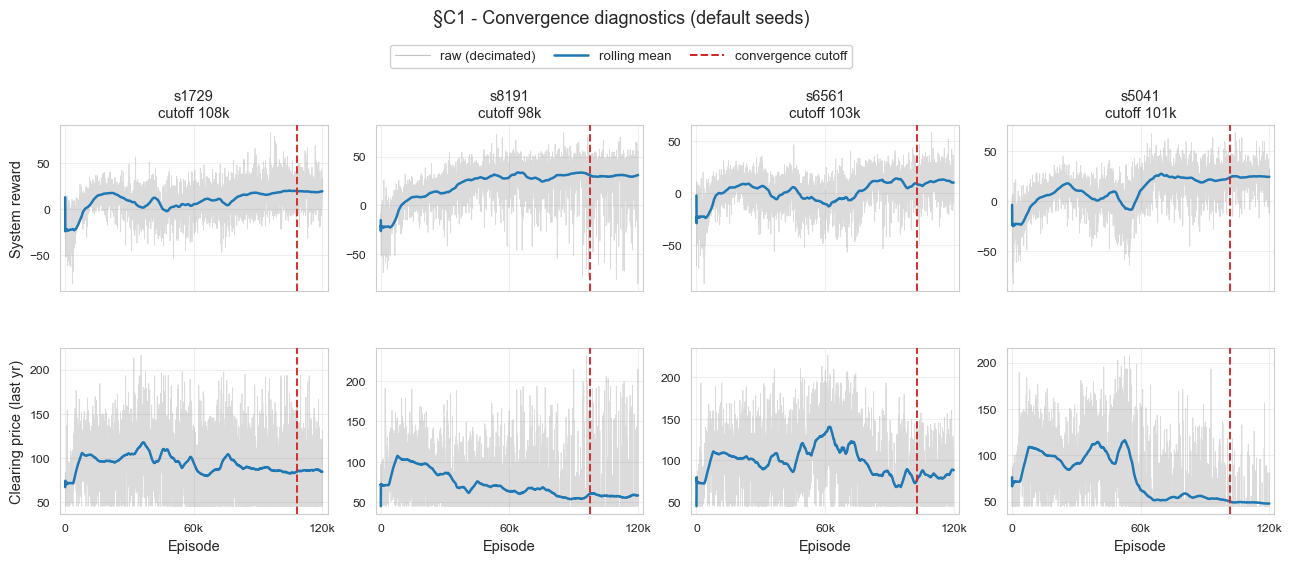

In [10]:
# Visualise convergence in a compact thesis layout while preserving the
# diagnostic grammar of the full grid below: grey raw trace, blue rolling
# mean, and a clear red cutoff line in each seed panel.
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

TARGET_DEFAULT_SEEDS = [1729, 8191, 6561, 5041]

plot_keys = [
    key for seed in TARGET_DEFAULT_SEEDS
    for key in sorted(DEFAULT_RUNS)
    if key[2] == seed
]

if not plot_keys:
    raise RuntimeError('No matching default seeds found for §C1 plot. Check loaded runs.')

metric_specs = [
    ('reward', 'System reward'),
    ('price',  'Clearing price (last yr)'),
]

max_episode = max(
    int(np.nanmax(sub['x_dec']))
    for key in plot_keys
    for metric, _ in metric_specs
    for sub in [plot_traces.get(key, {}).get(metric)]
    if sub
)
episode_ticks = [0, int(round(max_episode / 2, -3)), int(round(max_episode, -3))]
episode_formatter = FuncFormatter(lambda x, _: '0' if abs(x) < 1 else f'{x / 1000:.0f}k')

fig, axes = plt.subplots(2, len(plot_keys), figsize=(13.2, 5.8), sharex=True, squeeze=False)

for col_idx, key in enumerate(plot_keys):
    tr = plot_traces.get(key, {})
    cutoff = tr.get('cutoff')
    cutoff_label = f'{cutoff / 1000:.0f}k' if cutoff is not None else 'n/a'

    for row_idx, (name, ylabel) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        sub = tr.get(name)
        if not sub:
            ax.set_axis_off()
            continue

        ax.plot(sub['x_dec'], sub['y_dec'], lw=0.55, alpha=0.30, color='#888888', zorder=1)
        ax.plot(sub['sx_dec'], sub['sm_dec'], lw=1.8, color='C0', zorder=2)
        if cutoff is not None:
            ax.axvline(cutoff, color='C3', ls='--', lw=1.45, alpha=0.95, zorder=3)

        if row_idx == 0:
            ax.set_title(f's{key[2]}\ncutoff {cutoff_label}', fontsize=10.5)
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=10.5)
        if row_idx == len(metric_specs) - 1:
            ax.set_xlabel('Episode', fontsize=10.5)

        ax.set_xlim(-0.02 * max_episode, 1.02 * max_episode)
        ax.set_xticks(episode_ticks)
        ax.xaxis.set_major_formatter(episode_formatter)
        ax.tick_params(axis='both', labelsize=8.8)
        ax.grid(True, alpha=0.30, zorder=0)

legend_handles = [
    Line2D([0], [0], color='#888888', lw=0.8, alpha=0.5, label='raw (decimated)'),
    Line2D([0], [0], color='C0', lw=1.8, label='rolling mean'),
    Line2D([0], [0], color='C3', lw=1.45, ls='--', label='convergence cutoff'),
]

fig.suptitle('§C1 - Convergence diagnostics (default seeds)', y=0.99, fontsize=13)
fig.legend(
    handles=legend_handles,
    loc='upper center', bbox_to_anchor=(0.5, 0.94),
    ncol=3, fontsize=9.5, frameon=True, framealpha=0.92,
    handlelength=2.6, columnspacing=1.4,
)
fig.subplots_adjust(left=0.075, right=0.995, top=0.79, bottom=0.12, hspace=0.34, wspace=0.18)
plt.show()


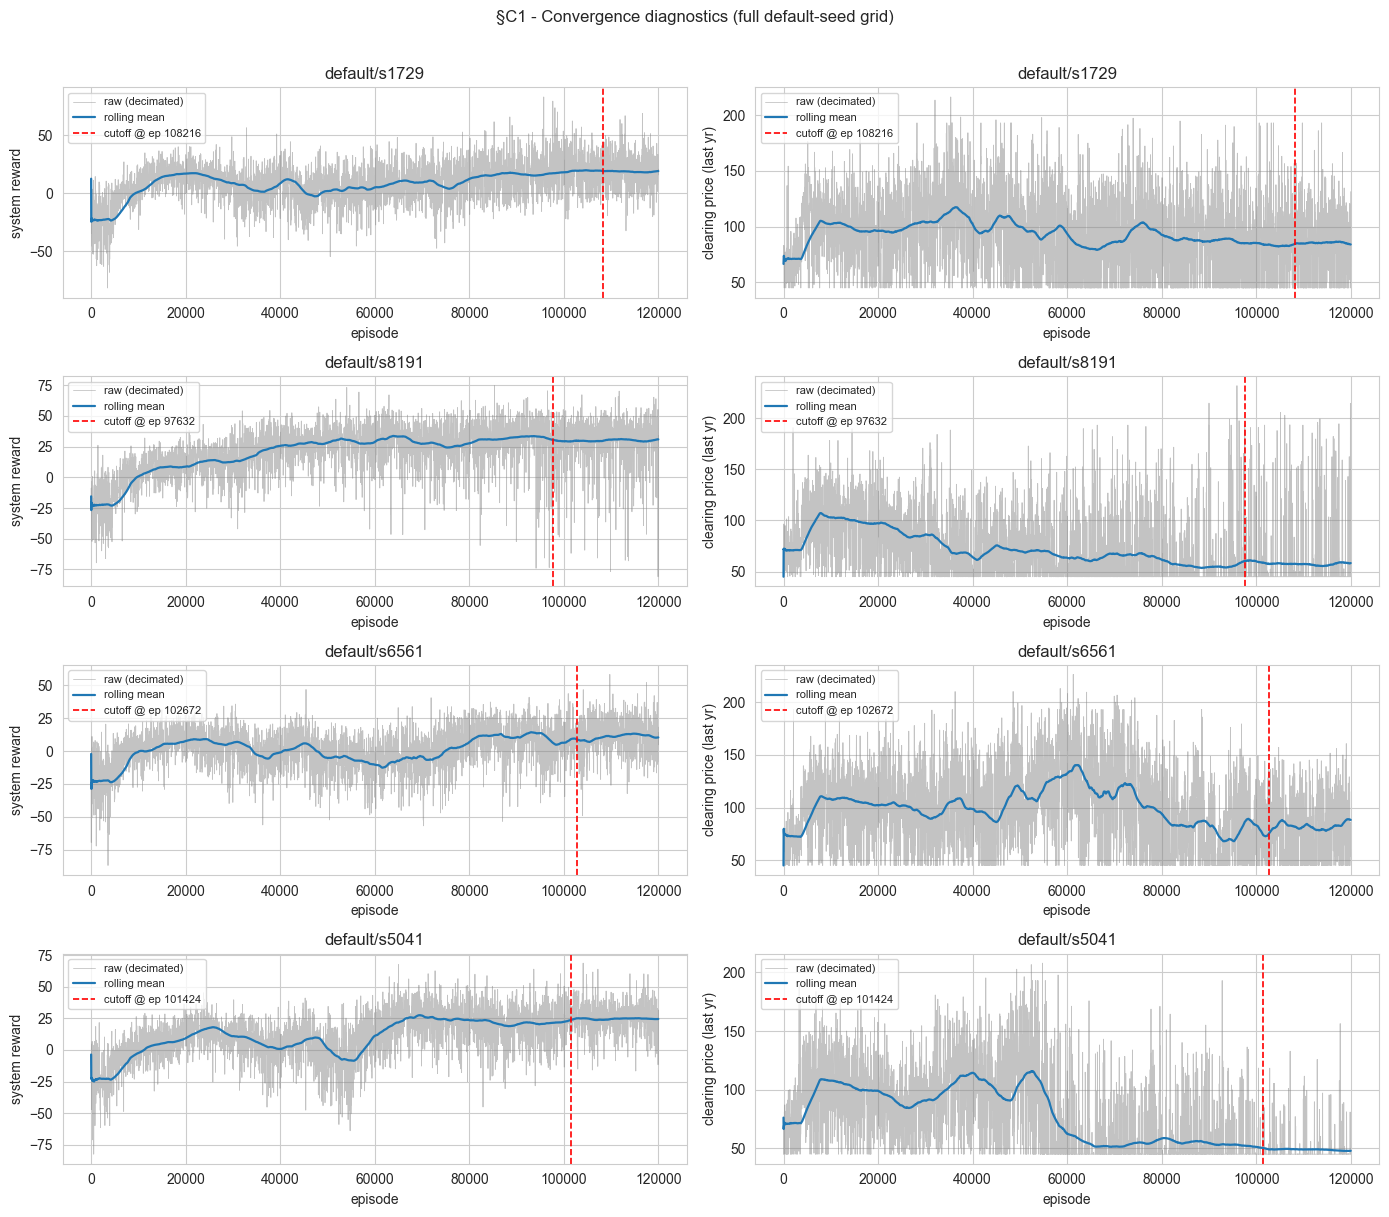

In [11]:
# Legacy full diagnostic grid: one row per default seed and two columns
# (reward, clearing price). This is useful for diagnostics, while the
# previous compact cell is better suited to an A4 thesis figure.
TARGET_DEFAULT_SEEDS = [1729, 8191, 6561, 5041]
plot_keys = [
    key for seed in TARGET_DEFAULT_SEEDS
    for key in sorted(DEFAULT_RUNS)
    if key[2] == seed
]

if not plot_keys:
    raise RuntimeError('No matching default seeds found for §C1 plot. Check loaded runs.')

n = len(plot_keys)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.0 * n), squeeze=False)
for row_idx, key in enumerate(plot_keys):
    tr = plot_traces.get(key, {})
    cutoff = tr.get('cutoff', 0)
    for ax, name, ylabel in [(axes[row_idx, 0], 'reward', 'system reward'),
                             (axes[row_idx, 1], 'price',  'clearing price (last yr)')]:
        sub = tr.get(name)
        if not sub:
            ax.set_axis_off(); continue
        ax.plot(sub['x_dec'], sub['y_dec'], lw=0.6, alpha=0.5, color='#888',
                label='raw (decimated)')
        ax.plot(sub['sx_dec'], sub['sm_dec'], lw=1.6, color='C0',
                label='rolling mean')
        ax.axvline(cutoff, color='red', ls='--', lw=1.2,
                   label=f'cutoff @ ep {cutoff}')
        ax.set(xlabel='episode', ylabel=ylabel, title=f'{key[1]}/s{key[2]}')
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle('§C1 - Convergence diagnostics (full default-seed grid)', y=1.01)
plt.tight_layout(); plt.show()


**Interpretation.** The two detectors should *broadly* agree on
where the trajectory levels off; we take the later of the two as the
conservative cutoff. With a 100-episode smoke run the detectors are
noisy by construction (insufficient samples for a stable rolling mean
or PELT prior), so the cutoff lands near the run end — that is
expected. On the production-scale sweep these cutoffs typically settle
around 60–80 % of `n_episodes`.

---

## §C2 — Cross-Seed Reproducibility (claim RQ1.b)

> Seed-bin fan charts on six headline metrics + a converged-window CV
> table. If converged-window CV is small relative to expected
> cross-variant differences, RQ2 / RQ3 claims are well-supported.

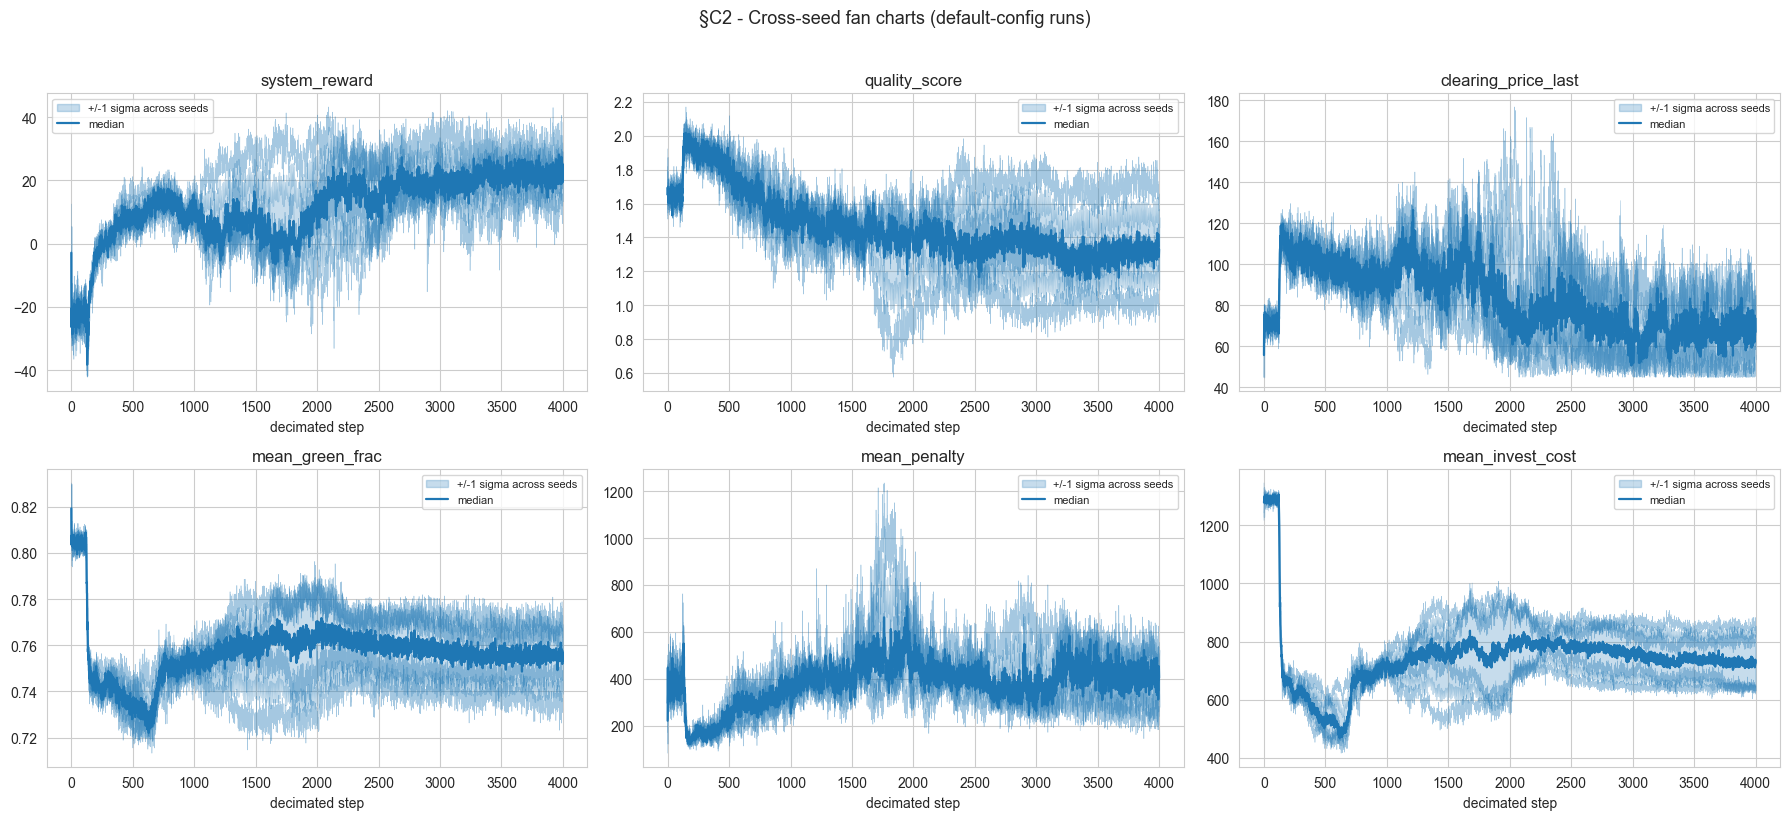

In [12]:
# Cross-seed fan charts from cached, smoothed+decimated headline traces
# (default-config runs only - cross-variant fan charts belong in §R1).
def _fan_panel(ax, name, traces):
    if not traces:
        ax.set_axis_off(); return
    L = min(len(s) for s in traces)
    arr = np.stack([s[:L] for s in traces])
    x = np.arange(L)
    med = np.median(arr, axis=0)
    lo, hi = np.percentile(arr, [16, 84], axis=0)
    ax.fill_between(x, lo, hi, alpha=0.25, color='C0', label='+/-1 sigma across seeds')
    ax.plot(x, med, color='C0', lw=1.6, label='median')
    for s in arr:
        ax.plot(x, s, color='C0', lw=0.4, alpha=0.4)
    ax.set(title=name, xlabel='decimated step')
    ax.legend(fontsize=8)


fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, (name, *_ ) in zip(axes.flat, HEADLINE_SPEC):
    _fan_panel(ax, name, headline_traces_default.get(name, []))
plt.suptitle('§C2 - Cross-seed fan charts (default-config runs)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


In [13]:
# Converged-window CV table from cached tail means (default-config runs).
default_keys = list(DEFAULT_RUNS)
rows = []
for name, *_ in HEADLINE_SPEC:
    vals = [headline_tail_means[k][name] for k in default_keys
            if k in headline_tail_means and np.isfinite(headline_tail_means[k].get(name, np.nan))]
    if not vals: continue
    arr = np.array(vals, dtype=float)
    mu = float(arr.mean()); sd = float(arr.std(ddof=1)) if len(arr) > 1 else float('nan')
    rows.append({'metric': name, 'n_seeds': len(arr),
                 'mean across seeds': mu, 'std across seeds': sd,
                 'cv (%)': 100.0 * sd / abs(mu) if mu else float('nan')})
cv_df = pd.DataFrame(rows)
display(cv_df.style.format({'mean across seeds': '{:.4g}', 'std across seeds': '{:.3g}', 'cv (%)': '{:.2f}'}))


,metric,n_seeds,mean across seeds,std across seeds,cv (%)
0,system_reward,4,21.14,8.1,38.31
1,quality_score,4,1.333,0.285,21.41
2,clearing_price_last,4,68.63,18.2,26.59
3,mean_green_frac,4,0.7545,0.0158,2.09
4,mean_penalty,4,405.8,131,32.40
5,mean_invest_cost,4,736.2,104,14.12


**Interpretation.** On the production sweep we want headline `cv (%)`
below ~10 %. On the smoke dataset (only 2 seeds × 100 episodes) the CVs
are large and uninterpretable — the table is shown as a sanity check
that the pipeline runs, not as evidence.

---

## §S1 — Strategy Archetypes in the Converged Market (claim RQ3.a)

Per-(run, agent) feature vector built from the converged window. We
cluster with KMeans (k chosen by **Silhouette + Elbow**), confirm with
hierarchical clustering (Ward linkage, dendrogram), visualise in 2D via
PCA, and cross-tabulate the emergent clusters against the **designed**
archetype × reward-weighting cells. The clustering pipeline produced
here is reused by §S2 (variant comparison) and §R1 (regulatory shifts).

*Feature-set extension:* the per-(run, agent) matrix also carries the **incompliance root-cause shares and means** (`incomp_*` — see §RQ4.5 of the Default-RQ notebook). They feed §S1's clustering and the §S4 correlation heatmap directly, so failure-mode signatures (e.g. *underbid-driven* vs *inherited-debt-driven* agents) emerge as part of the strategy taxonomy.


In [14]:
# Per-(run, agent) feature matrix `feat_df` was built during the
# streaming pre-compute. Listed here are the column families it carries.
EPISODE_FEATURES = ['bid_price', 'avg_bid_mult', 'inv_onshore_share',
                    'inv_offshore_share', 'inv_solar_share', 'green_frac',
                    'invest_cost', 'penalty',
                    'peak_loan_outstanding', 'peak_carry_forward',
                    'final_treasury_reserve']
YEAR_FEATURES    = ['sec_buy_vol', 'sec_sell_vol',
                    'coverage_gap', 'effective_penalty_rate',
                    'carry_forward_end', 'treasury_reserve',
                    'loan_outstanding']
# Per-(run, agent) incompliance root-cause attribution; mirrors §RQ4.5 of the
# Default-RQ notebook. See the streaming pre-compute (§5b) for the cell-level
# waterfall used to build these aggregates.
INCOMP_FEATURES  = ['incomp_n_years',
                    'incomp_total_shortfall_Mt',
                    'incomp_share_inherited',
                    'incomp_share_underbid',
                    'incomp_share_undersize',
                    'incomp_share_oversubscribed',
                    'incomp_share_secondary_unmet',
                    'incomp_mean_bid_to_clearing',
                    'incomp_mean_oversubscription',
                    'incomp_mean_inherited_debt_Mt']
UDBC_BUCKETS     = ['U', 'D', 'M', 'B', 'C']


def feature_columns(df):
    base = (list(EPISODE_FEATURES) + list(YEAR_FEATURES)
            + list(INCOMP_FEATURES)
            + [f'udbc_{b}_share' for b in UDBC_BUCKETS])
    return [c for c in base if c in df.columns]


# Filter feat_df to default-config rows for §S1 cluster fit; the override
# rows (used by §S2 / §R1.a) are projected into the same basis below.
default_feat_df = feat_df[~feat_df['has_overrides']].reset_index(drop=True)
print(f'Per-(run, agent) feature matrix - default rows: {default_feat_df.shape[0]} '
      f'rows x {default_feat_df.shape[1]} cols  '
      f'(full feat_df incl. overrides: {feat_df.shape[0]} rows)')
display(default_feat_df.head())


Per-(run, agent) feature matrix - default rows: 32 rows x 40 cols  (full feat_df incl. overrides: 160 rows)


,sweep,variant,seed,agent,archetype,weighting,has_overrides,bid_price,avg_bid_mult,inv_onshore_share,inv_offshore_share,inv_solar_share,green_frac,invest_cost,penalty,peak_loan_outstanding,peak_carry_forward,final_treasury_reserve,sec_buy_vol,sec_sell_vol,coverage_gap,effective_penalty_rate,carry_forward_end,treasury_reserve,loan_outstanding,udbc_U_share,udbc_D_share,udbc_M_share,udbc_B_share,udbc_C_share,incomp_n_years,incomp_total_shortfall_Mt,incomp_share_inherited,incomp_share_underbid,incomp_share_undersize,incomp_share_oversubscribed,incomp_share_secondary_unmet,incomp_mean_bid_to_clearing,incomp_mean_oversubscription,incomp_mean_inherited_debt_Mt
0,default_seeds,default,1729,1,coal-leaning,pure_financial,False,153.462021,0.510219,0.007988,0.980106,0.011905,0.602189,1015.234619,1374.809570,0.0,1.815351,1009.070007,NaN,NaN,1.814443,155.08931,0.723660,891.457947,0.0,0.155224,0.101531,0.257623,0.242380,0.243242,72214.0,102331.360277,0.197386,0.006273,0.790387,0.005955,0.000000,2.564766,1.528456,1.035048
1,default_seeds,default,1729,2,coal-leaning,balanced_esg,False,148.873383,0.510000,0.452059,0.000636,0.547304,0.606528,857.955872,172.490326,0.0,0.587344,1134.812988,NaN,NaN,1.488726,155.08931,0.085579,912.078979,0.0,0.078689,0.003305,0.041479,0.502639,0.373888,17262.0,12101.546355,0.026764,0.002723,0.968949,0.001564,0.000000,2.450515,1.648345,0.269271
2,default_seeds,default,1729,3,balanced,pure_financial,False,49.335190,1.980280,0.007734,0.980912,0.011353,0.578302,22.547009,80.776573,0.0,0.334153,968.702637,NaN,NaN,1.790823,155.08931,0.041090,838.126038,0.0,0.067984,0.000829,0.019497,0.282087,0.629602,10327.0,5810.492255,0.009393,0.660502,0.004648,0.325361,0.000097,0.716255,1.633228,0.244144
3,default_seeds,default,1729,4,balanced,balanced_esg,False,85.635864,1.974570,0.987402,0.000551,0.012047,0.767965,1547.267334,86.470978,0.0,0.364150,1158.594116,NaN,NaN,0.346792,155.08931,0.044654,922.605957,0.0,0.199440,0.022104,0.041861,0.601373,0.135222,10439.0,6314.419652,0.083916,0.349267,0.017530,0.549286,0.000000,0.921636,1.724593,0.179299
4,default_seeds,default,1729,5,transitioner,pure_financial,False,160.665695,1.252872,0.007833,0.980262,0.011905,0.730036,28.477589,69.548042,0.0,0.283978,977.638672,NaN,NaN,0.250371,155.08931,0.034393,822.728455,0.0,0.120961,0.013814,0.037662,0.816036,0.011527,9125.0,4863.429798,0.080110,0.009973,0.903233,0.006685,0.000000,2.730022,1.604341,0.157142


Feature columns kept after variance filter: ['bid_price', 'avg_bid_mult', 'inv_onshore_share', 'inv_offshore_share', 'inv_solar_share', 'green_frac', 'invest_cost', 'penalty', 'peak_loan_outstanding', 'peak_carry_forward', 'final_treasury_reserve', 'coverage_gap', 'effective_penalty_rate', 'carry_forward_end', 'treasury_reserve', 'loan_outstanding', 'incomp_n_years', 'incomp_total_shortfall_Mt', 'incomp_share_inherited', 'incomp_share_underbid', 'incomp_share_undersize', 'incomp_share_oversubscribed', 'incomp_share_secondary_unmet', 'incomp_mean_bid_to_clearing', 'incomp_mean_oversubscription', 'incomp_mean_inherited_debt_Mt', 'udbc_U_share', 'udbc_D_share', 'udbc_M_share', 'udbc_B_share', 'udbc_C_share']
X shape: (32, 31)


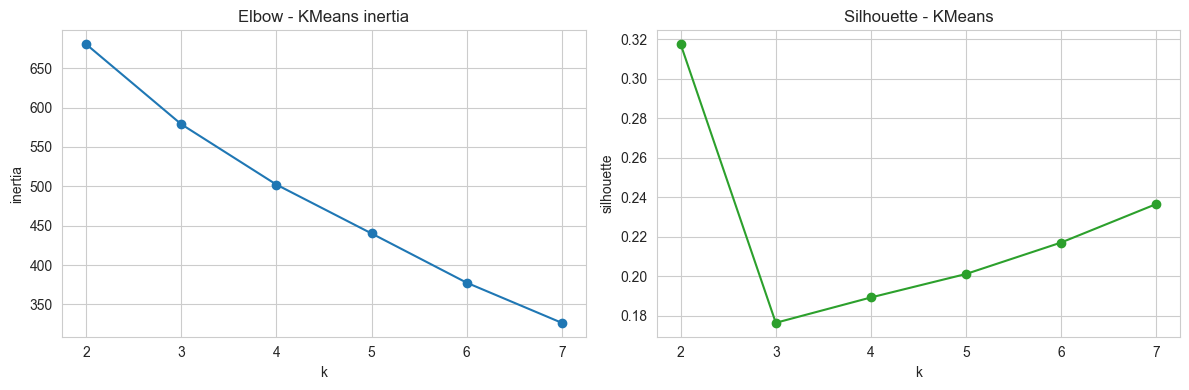

Selected k = 2 (max silhouette).


In [15]:
# Standardise + KMeans with Silhouette/Elbow on default-config rows only.
def _prepare_X(df):
    feats = feature_columns(df)
    X = df[feats].values.astype(float)
    keep = []
    for j in range(X.shape[1]):
        col = X[:, j]
        col = col[np.isfinite(col)]
        if len(col) > 0 and np.nanstd(col) > 1e-12:
            keep.append(j)
    feats = [feats[j] for j in keep]
    X = X[:, keep]
    col_means = np.nanmean(X, axis=0)
    nan_mask = ~np.isfinite(X)
    X[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
    scaler = StandardScaler().fit(X)
    return scaler.transform(X), feats, scaler


X, feats, scaler = _prepare_X(default_feat_df)
print('Feature columns kept after variance filter:', feats)
print('X shape:', X.shape)

K_RANGE = range(2, min(8, len(X)))
sil_scores, inertias = [], []
for k in K_RANGE:
    if k >= len(X):
        sil_scores.append(np.nan); inertias.append(np.nan); continue
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertias.append(km.inertia_)
    try:
        sil_scores.append(silhouette_score(X, km.labels_))
    except Exception:
        sil_scores.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-')
axes[0].set(title='Elbow - KMeans inertia', xlabel='k', ylabel='inertia')
axes[1].plot(list(K_RANGE), sil_scores, 'o-', color='C2')
axes[1].set(title='Silhouette - KMeans', xlabel='k', ylabel='silhouette')
plt.tight_layout(); plt.show()

valid = [(k, s) for k, s in zip(K_RANGE, sil_scores) if np.isfinite(s)]
K_BEST = max(valid, key=lambda kv: kv[1])[0] if valid else 3
print(f'Selected k = {K_BEST} (max silhouette).')


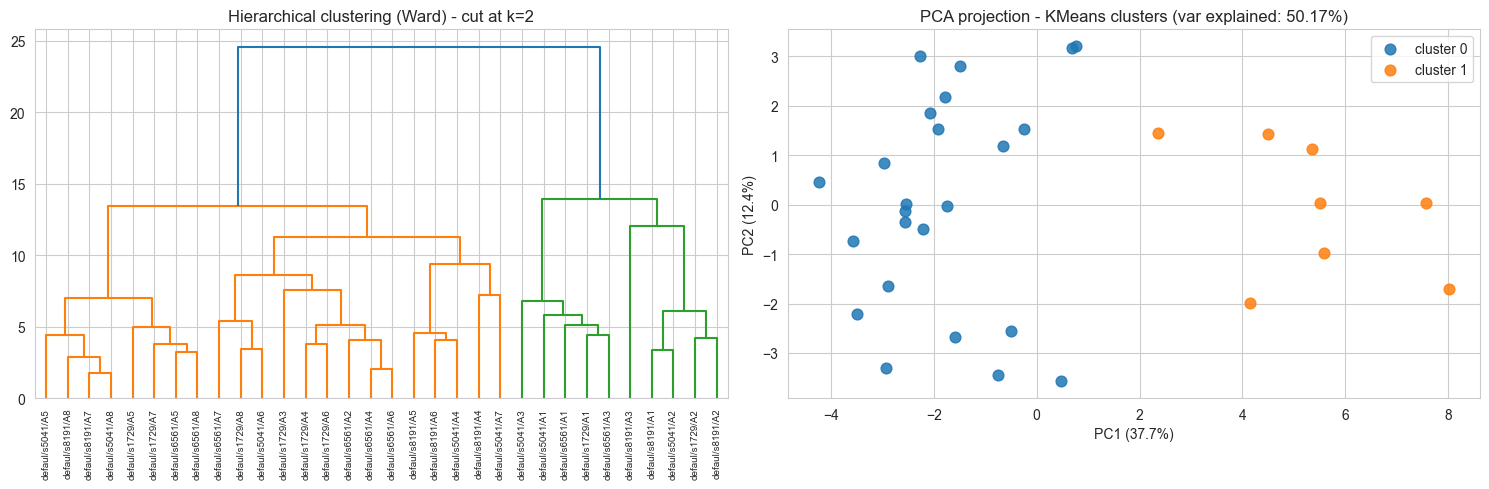

In [16]:
# Final KMeans + hierarchical confirmation on default-config rows.
km = KMeans(n_clusters=K_BEST, n_init=20, random_state=0).fit(X)
default_feat_df = default_feat_df.copy()
default_feat_df['kmeans_cluster'] = km.labels_

Z = linkage(X, method='ward')
hier_labels = fcluster(Z, t=K_BEST, criterion='maxclust')
default_feat_df['hier_cluster'] = hier_labels

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
labels = [f"{r['variant'][:6]}/s{r['seed']}/A{r['agent']}" for _, r in default_feat_df.iterrows()]
dendrogram(Z, labels=labels, leaf_rotation=90, ax=axes[0])
axes[0].set(title=f'Hierarchical clustering (Ward) - cut at k={K_BEST}')
axes[0].tick_params(axis='x', labelsize=7)

pca = PCA(n_components=2, random_state=0).fit(X)
P = pca.transform(X)
ax = axes[1]
for c in range(K_BEST):
    sel = km.labels_ == c
    ax.scatter(P[sel, 0], P[sel, 1], label=f'cluster {c}', s=60, alpha=0.85)
ax.set(title=f'PCA projection - KMeans clusters (var explained: {pca.explained_variance_ratio_.sum():.2%})',
       xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend()
plt.tight_layout(); plt.show()


In [17]:
ct = pd.crosstab(
    [default_feat_df['archetype'], default_feat_df['weighting']],
    default_feat_df['kmeans_cluster'],
    margins=True,
)
print('Designed archetype x weighting  vs  KMeans cluster:')
display(ct)

ct_h = pd.crosstab(
    [default_feat_df['archetype'], default_feat_df['weighting']],
    default_feat_df['hier_cluster'],
    margins=True,
)
print('Designed archetype x weighting  vs  Hierarchical cluster:')
display(ct_h)


Designed archetype x weighting  vs  KMeans cluster:


kmeans_cluster                0  1  All
archetype    weighting                 
balanced     balanced_esg     4  0    4
             pure_financial   1  3    4
coal-leaning balanced_esg     3  1    4
             pure_financial   0  4    4
green-leader balanced_esg     4  0    4
             pure_financial   4  0    4
transitioner balanced_esg     4  0    4
             pure_financial   4  0    4
All                          24  8   32

Designed archetype x weighting  vs  Hierarchical cluster:


hier_cluster                  1   2  All
archetype    weighting                  
balanced     balanced_esg     4   0    4
             pure_financial   1   3    4
coal-leaning balanced_esg     1   3    4
             pure_financial   0   4    4
green-leader balanced_esg     4   0    4
             pure_financial   4   0    4
transitioner balanced_esg     4   0    4
             pure_financial   4   0    4
All                          22  10   32

**Interpretation.** A diagonal-ish cross-tab indicates the
emergent clustering recovers the designed archetypes. Off-diagonal mass
is itself a finding (e.g. archetype heterogeneity collapsing under a
specific reward weighting, or two archetypes converging onto the same
strategy). The hierarchical and KMeans tables should agree on the
qualitative grouping — when they don't, the strategy space is
ambiguous and the headline claim needs hedging.

In [18]:
# Persist the fitted feature space so §S2 and §R1 can project new
# (variant, seed, agent) feature vectors into the *same* space.
S1_ARTIFACTS = dict(scaler=scaler, pca=pca, kmeans=km, feature_cols=feats, k=K_BEST)
print('Stored S1 artefacts: scaler, PCA, KMeans, feature_cols.')

Stored S1 artefacts: scaler, PCA, KMeans, feature_cols.


---

## §S4 — Strategy-Feature Correlation Heatmap

Per-(run, agent) feature correlations across the same matrix used in §S1.
Useful for the thesis interpretation pass: tells us which strategy axes are
near-collinear (so a single PC explains most of the relevant variance) and
which are independent.


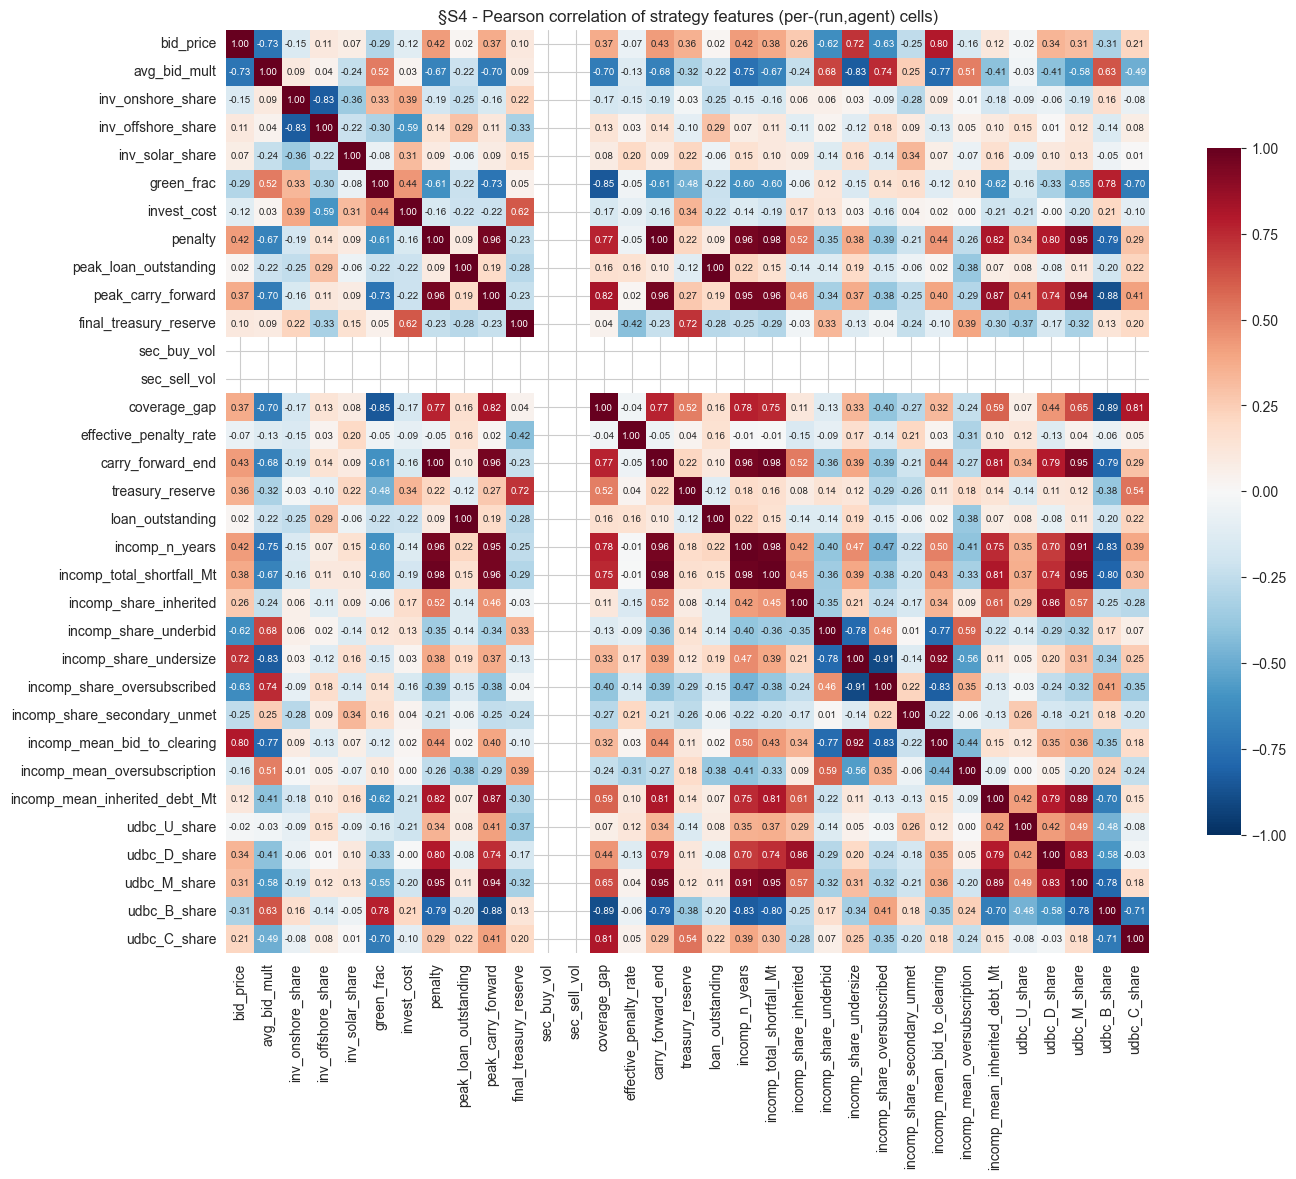

Near-collinear feature pairs (|r| >= 0.9):


,feature_a,feature_b,pearson_r
5,peak_loan_outstanding,loan_outstanding,1.000
1,penalty,carry_forward_end,1.000
3,penalty,incomp_total_shortfall_Mt,0.984
11,carry_forward_end,incomp_total_shortfall_Mt,0.984
13,incomp_n_years,incomp_total_shortfall_Mt,0.979
8,peak_carry_forward,incomp_total_shortfall_Mt,0.960
10,carry_forward_end,incomp_n_years,0.959
0,penalty,peak_carry_forward,0.956
2,penalty,incomp_n_years,0.956
6,peak_carry_forward,carry_forward_end,0.956


In [19]:
# Pearson correlation across §S1 features on default-config rows.
_corr_feats = feature_columns(default_feat_df)
if _corr_feats and len(default_feat_df) >= 4:
    C = default_feat_df[_corr_feats].corr()
    fig, ax = plt.subplots(figsize=(min(14, 0.45 * len(_corr_feats) + 4),
                                    min(12, 0.45 * len(_corr_feats) + 3)))
    sns.heatmap(C, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
                square=True, cbar_kws={'shrink': 0.7}, ax=ax,
                annot_kws={'size': 7})
    ax.set_title('§S4 - Pearson correlation of strategy features (per-(run,agent) cells)')
    plt.tight_layout(); plt.show()
    pairs = []
    for i, a in enumerate(_corr_feats):
        for j, b in enumerate(_corr_feats):
            if j <= i: continue
            r = float(C.iloc[i, j])
            if abs(r) >= 0.9:
                pairs.append({'feature_a': a, 'feature_b': b, 'pearson_r': round(r, 3)})
    if pairs:
        print('Near-collinear feature pairs (|r| >= 0.9):')
        display(pd.DataFrame(pairs).sort_values('pearson_r', key=abs, ascending=False))
    else:
        print('No feature pairs with |r| >= 0.9 - features are reasonably independent.')
else:
    print('§S4 skipped - feature matrix too small or empty.')


---

## §S2 — How Reward Weights Shape Strategy (claim RQ3.b)

This is the headline RQ3 analysis. We use **two complementary contrasts**:

1. **Within the default config:** every default run already mixes
   pure-financial agents (`reward_weights=[1,0]`) with balanced-ESG
   agents (`reward_weights=[0.5,0.5]`). We project them into the §S1
   PCA space and compare centroid positions and within-group spread.
2. **Cross-variant (when available):** if the loaded sweeps include an
   `all_financial`-style variant (every learning agent with
   `[w_cost=1, w_green=0]`), we re-run the §S1 clustering on that
   variant's per-agent feature matrix and compare cluster count, spread
   in the §S1 PCA basis, and silhouette score against the default.

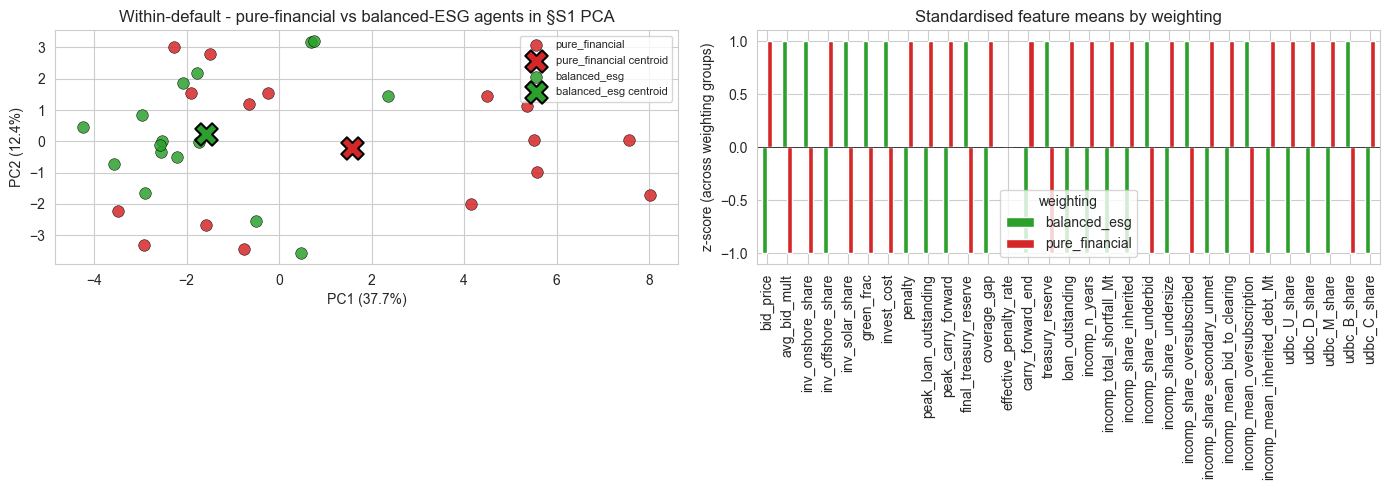

In [20]:
# Within-default contrast - pure_financial vs balanced_esg agents in PCA.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for w, color in [('pure_financial', 'C3'), ('balanced_esg', 'C2')]:
    sel = (default_feat_df['weighting'] == w).values
    if sel.sum():
        ax.scatter(P[sel, 0], P[sel, 1], label=w, color=color, s=70, alpha=0.85,
                   edgecolor='k', linewidth=0.4)
        cx, cy = P[sel, 0].mean(), P[sel, 1].mean()
        ax.scatter([cx], [cy], marker='X', s=260, color=color, edgecolor='black',
                   linewidth=1.5, label=f'{w} centroid')
ax.set(title='Within-default - pure-financial vs balanced-ESG agents in §S1 PCA',
       xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=8)

ax = axes[1]
mu = default_feat_df.groupby('weighting')[feats].mean()
mu_std = (mu - mu.mean()) / (mu.std(ddof=0) + 1e-9)
mu_std.T.plot(kind='bar', ax=ax, color=['C2', 'C3'])
ax.axhline(0, color='k', lw=0.5)
ax.set(title='Standardised feature means by weighting',
       ylabel='z-score (across weighting groups)', xlabel='')
ax.legend(title='weighting')
plt.tight_layout(); plt.show()


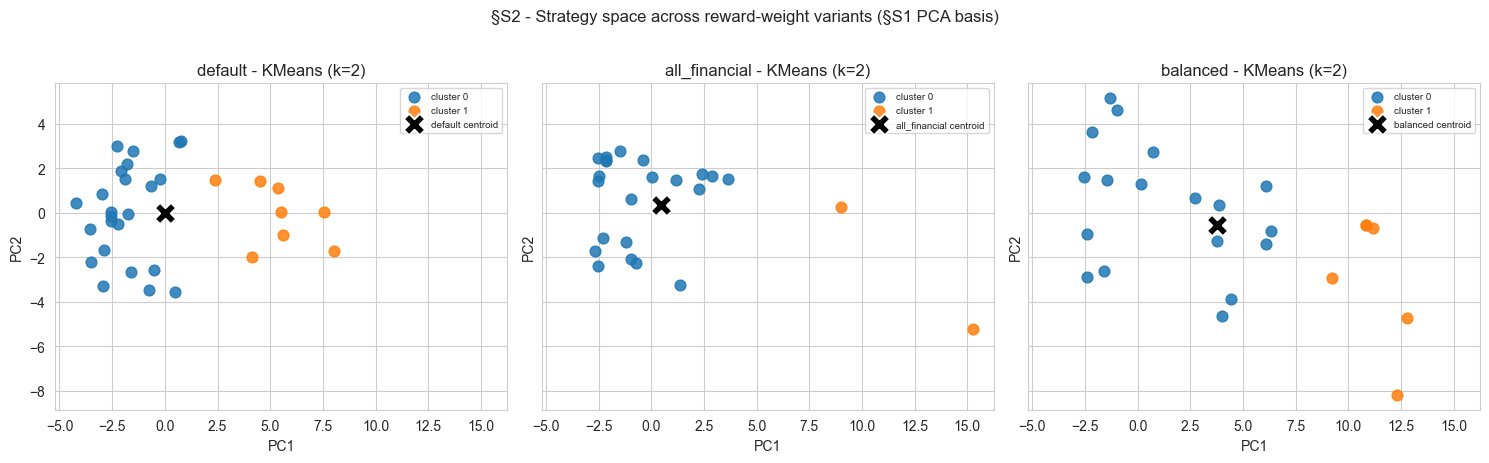

,variant,n,silhouette,k_best,mean radius (PC1-PC2)
0,default,32,0.317453,2,3.635082
1,all_financial,24,0.538542,2,3.615627
2,balanced,24,0.355202,2,5.366954


Headline RQ3.b read: lower silhouette / smaller PC-radius in `all_financial` (or `balanced` with all financial agents) versus `default` is evidence that the ESG component drives strategic heterogeneity.
Outcome comparison across reward-weighting variants:


green_frac                      penalty                   clearing_price                 
                    mean       std count         mean         std count           mean        std count
group                                                                                                  
all_financial   0.742277  0.041240     3   480.111043  251.877778     3      67.417937  22.180356     3
balanced        0.611999  0.030991     3  1355.816732  468.027039     3      96.116594  62.768246     3
default         0.754510  0.015769     4   405.810497  131.483057     4      68.626212  18.248096     4

In [21]:
# Cross-variant contrast. Both `feat_df` (full) and `green_means_per_run`
# (cached during pre-compute) are read from artefacts; no runs are reloaded.
def _matches(variant, *needles):
    return any(n in variant for n in needles)

af_keys  = [k for k, v in OVERRIDE_RUNS.items()
            if _matches(v['variant'], 'all_fin', 'all_financial')]
bal_keys = [k for k, v in OVERRIDE_RUNS.items()
            if _matches(v['variant'], 'balanced')]


def _project_keys(key_list):
    """Slice feat_df to the given run keys, project into the §S1 basis."""
    if not key_list:
        return np.empty((0, 2)), np.empty((0, len(feats))), 0
    mask = feat_df.set_index(['sweep', 'variant', 'seed']).index.isin(key_list)
    sub = feat_df[mask]
    if sub.empty:
        return np.empty((0, 2)), np.empty((0, len(feats))), 0
    Xv = sub[feats].values.astype(float)
    col_means = np.nanmean(Xv, axis=0)
    nan_mask = ~np.isfinite(Xv)
    Xv[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
    Xv_std = scaler.transform(Xv)
    return pca.transform(Xv_std), Xv_std, len(Xv)


def _silhouette_sweep(X_std, k_max=8):
    if len(X_std) < 4:
        return [], None, None
    rng = range(2, min(k_max, len(X_std)))
    sils = []
    for k in rng:
        if k >= len(X_std):
            sils.append(np.nan); continue
        km_ = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
        try:
            sils.append(silhouette_score(X_std, km_.labels_))
        except Exception:
            sils.append(np.nan)
    valid = [(k, s) for k, s in zip(rng, sils) if np.isfinite(s)]
    if not valid:
        return sils, None, None
    k_best = max(valid, key=lambda kv: kv[1])[0]
    km_final = KMeans(n_clusters=k_best, n_init=20, random_state=0).fit(X_std)
    return sils, k_best, km_final


def _spread(P_):
    return float(np.mean(np.linalg.norm(P_ - P_.mean(axis=0), axis=1))) if len(P_) else float('nan')


summary_rows = [{'variant': 'default', 'n': len(P),
                 'silhouette': max(sil_scores) if sil_scores else np.nan,
                 'k_best': K_BEST, 'mean radius (PC1-PC2)': _spread(P)}]

panels = [('default', P, km.labels_, f'default - KMeans (k={K_BEST})')]

for label, key_list in [('all_financial', af_keys), ('balanced', bal_keys)]:
    if not key_list:
        print(f'§S2 - {label} variant not loaded - panel skipped.')
        continue
    Pv, Xv_std, nv = _project_keys(key_list)
    sils_v, k_v, km_v = _silhouette_sweep(Xv_std)
    panels.append((label, Pv,
                   km_v.labels_ if km_v is not None else np.zeros(nv, dtype=int),
                   f'{label} - KMeans (k={k_v})' if k_v else f'{label} (n={nv})'))
    summary_rows.append({
        'variant': label, 'n': nv,
        'silhouette': max(sils_v) if sils_v else np.nan,
        'k_best': k_v, 'mean radius (PC1-PC2)': _spread(Pv),
    })

n_panels = len(panels)
fig, axes = plt.subplots(1, n_panels, figsize=(5.0 * n_panels, 4.5),
                         sharex=True, sharey=True, squeeze=False)
for ax, (title_lab, points, lbls, title) in zip(axes[0], panels):
    if len(points) == 0:
        ax.set_axis_off(); continue
    for c in np.unique(lbls):
        sel = lbls == c
        ax.scatter(points[sel, 0], points[sel, 1], s=60, alpha=0.85, label=f'cluster {c}')
    ax.scatter(points[:, 0].mean(), points[:, 1].mean(), marker='X', s=240,
               color='k', edgecolor='white', linewidth=1.5, label=f'{title_lab} centroid')
    ax.set(title=title, xlabel='PC1', ylabel='PC2')
    ax.legend(fontsize=7)
plt.suptitle('§S2 - Strategy space across reward-weight variants (§S1 PCA basis)', y=1.02)
plt.tight_layout(); plt.show()

display(pd.DataFrame(summary_rows))
print('Headline RQ3.b read: lower silhouette / smaller PC-radius in `all_financial`'
      ' (or `balanced` with all financial agents) versus `default` is evidence that'
      ' the ESG component drives strategic heterogeneity.')


def _green_summary(key_list):
    rows = []
    for k in key_list:
        gm = green_means_per_run.get(k)
        if gm is None: continue
        rows.append({'variant': k[1], 'seed': k[2], **gm})
    return pd.DataFrame(rows)


outcomes = [_green_summary(list(DEFAULT_RUNS)).assign(group='default')]
if af_keys:  outcomes.append(_green_summary(af_keys).assign(group='all_financial'))
if bal_keys: outcomes.append(_green_summary(bal_keys).assign(group='balanced'))
if len(outcomes) > 1:
    out_cmp = (pd.concat(outcomes, ignore_index=True)
                  .groupby('group')[['green_frac', 'penalty', 'clearing_price']]
                  .agg(['mean', 'std', 'count']))
    print('Outcome comparison across reward-weighting variants:')
    display(out_cmp)


**Interpretation.** The within-default contrast is the lower-bar
evidence: even *inside* the same training run, balanced-ESG agents
should sit further along whichever PC tracks green investment than
their pure-financial twins. The cross-variant comparison is the
stronger test: if the all-financial variant collapses to fewer
clusters and a tighter PCA cloud, removing the ESG component is
*causing* strategic homogenisation. If the spread does **not**
collapse, agents found other reasons to differentiate (cost-structure
heterogeneity, urgency scalars, etc.) — a finding worth reporting
honestly.

---

## §S3 — Are Strategies Economically Rational? (claim RQ3.c, Tier 2)

For this section only, the hypothesis tests use a larger default-config evidence base than the rest of the notebook: the original four `default_seeds.yaml` seeds plus the default variant seeds listed in `default_seeds_expanded.yaml`. Earlier sections keep using the registry / streaming pre-compute configured in §3-§5b.

Three sub-analyses:

* **H1.** *Carbon price drives green investment.* Per-(run, agent, year):
  label = 1 if `invest_cost > threshold`. Features = lag-1 clearing price,
  archetype dummies, agent bank at start of year, year. Logistic
  regression with **L1/LASSO** (Lecture 4 + 8) and a **Random Forest**
  for the partial-dependence cross-check on the lagged carbon price.
* **H2.** *High-fossil agents transition faster.* Label = 1 if the
  agent's `delta_green` over the episode exceeds the median. Features =
  initial mix, archetype dummies, mean clearing price seen by the
  agent. Same LASSO + RF setup.
* **Anchor check.** Realised mean clearing price per year (across runs)
  vs `compute_fundamental_anchor(year, config)`. One overlay plot,
  Pearson correlation, and mean absolute deviation.

§S3 default seeds:   0%|          | 0/8 [00:00<?, ?seed/s]

§S3 default-only evidence base:
  seeds loaded (8): [317, 431, 683, 947, 1729, 5041, 6561, 8191]
  H1/H2 panel rows: 768 per-(run, agent, year) rows
  Episodes used are the converged-tail episodes per seed (episode >= analysis_start_episode).


,sweep,seed,n_episodes_total,detected_convergence_cutoff,analysis_start_episode,episodes_used,episode_share_used,year_log_rows_used,agent_year_rows
0,default_seeds,1729,120000,108216,108216,11784,9.8%,141408,96
1,default_seeds,5041,120000,101424,101424,18576,15.5%,222912,96
2,default_seeds,6561,120000,102672,102672,17328,14.4%,207936,96
3,default_seeds,8191,120000,97632,97632,22368,18.6%,268416,96
4,default_seeds_expanded,317,120000,110136,110136,9864,8.2%,118368,96
5,default_seeds_expanded,431,120000,76920,76920,43080,35.9%,516960,96
6,default_seeds_expanded,683,120000,112560,112560,7440,6.2%,89280,96
7,default_seeds_expanded,947,120000,105888,105888,14112,11.8%,169344,96


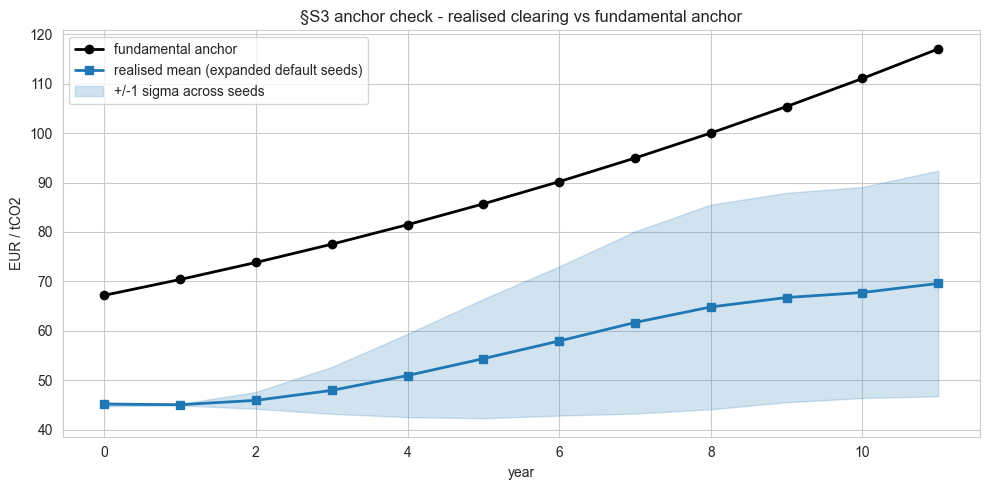

Pearson correlation (realised, anchor): +0.985
Mean absolute deviation: 33.04 EUR/t


In [22]:
# §S3-only expanded default-seed panel. This does not mutate `runs`,
# `pay_df`, or `clearing_per_year_df`, so earlier/later sections keep the
# experiment scope configured in §3-§5b.
S3_DEFAULT_SWEEP_SPECS = [
    PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds.yaml',
    PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds_expanded.yaml',
]

# Search the canonical sweep folder first, then the literal output_dir used
# by each spec. This covers both the old `results/default` layout and the
# current co-located `results/sweeps/default` parquet cache.
S3_OUTPUT_DIR_CANDIDATES = [
    PROJECT_ROOT / 'results' / 'sweeps' / 'default',
    PROJECT_ROOT / 'results' / 'sweeps',
    PROJECT_ROOT / 'results',
]

# Keep the thesis methodology aligned with §C1: H1/H2 use the converged
# tail only. The table printed below reports exactly how many episodes from
# each seed survive this cutoff.
S3_USE_CONVERGED_TAIL = True

S3_EP_COLS = ['episode', 'clearing_price_last'] + [f'reward_A{i+1}' for i in range(N_AGENTS)]
S3_YR_COLS = ['episode', 'year', 'clearing_price'] + [
    f'{prefix}_A{i+1}'
    for prefix in ('invest_cost', 'bank_start')
    for i in range(N_AGENTS)
]


def _s3_resolve_default_files(seed, spec_output_dir, variant_name='default'):
    """Find default-run training/year logs for one seed, accepting CSV or parquet."""
    search_dirs = []
    for base in [spec_output_dir, *S3_OUTPUT_DIR_CANDIDATES]:
        if base is None:
            continue
        base = Path(base)
        search_dirs.extend([base / variant_name, base])

    # Reuse any exact registry location when the original §3 registry already
    # knows about this seed.
    for entry in runs.values():
        if entry.get('variant') == variant_name and int(entry.get('seed')) == int(seed):
            if entry.get('training_log'):
                search_dirs.append(Path(entry['training_log']).parent)
            if entry.get('year_log'):
                search_dirs.append(Path(entry['year_log']).parent)

    search_dirs = list(dict.fromkeys(search_dirs))
    training_names = [f'training_log_{variant_name}_s{seed}.csv', f'training_log_s{seed}.csv']
    year_names     = [f'year_log_{variant_name}_s{seed}.csv',     f'year_log_s{seed}.csv']

    tlog = ylog = None
    for base in search_dirs:
        if tlog is None:
            for name in training_names:
                path = base / name
                if log_exists(path):
                    tlog = path
                    break
        if ylog is None:
            for name in year_names:
                path = base / name
                if log_exists(path):
                    ylog = path
                    break
        if tlog is not None and ylog is not None:
            break
    return tlog, ylog


def _s3_default_run_registry():
    """Return default-config run entries promised by the two §S3 seed specs."""
    by_seed = {}
    missing = []

    for spec_path in S3_DEFAULT_SWEEP_SPECS:
        spec = load_sweep_spec(str(spec_path))
        base_cfg_path = (PROJECT_ROOT / spec['base_config']).resolve()
        with open(base_cfg_path, encoding='utf-8') as f:
            base_cfg = yaml.safe_load(f)
        spec_output_dir = (PROJECT_ROOT / spec['output_dir']).resolve()
        sweep_name = Path(spec_path).stem

        for variant in spec.get('variants', []):
            variant_name = variant.get('name')
            overrides = variant.get('overrides') or {}
            if variant_name != 'default' or overrides:
                continue

            seeds = variant.get('seeds') or spec.get('seeds') or []
            cfg = deep_merge(base_cfg, expand_dotted_overrides(overrides))
            for seed in seeds:
                seed = int(seed)
                if seed in by_seed:
                    continue
                tlog, ylog = _s3_resolve_default_files(seed, spec_output_dir, variant_name)
                if tlog is None or ylog is None:
                    missing.append({'sweep': sweep_name, 'seed': seed, 'training_log': tlog, 'year_log': ylog})
                    continue
                by_seed[seed] = {
                    'sweep': sweep_name,
                    'variant': variant_name,
                    'seed': seed,
                    'config': cfg,
                    'training_log': str(tlog),
                    'year_log': str(ylog),
                }

    if missing:
        print('§S3 warning - requested default seeds with missing logs:')
        display(pd.DataFrame(missing))
    return [by_seed[s] for s in sorted(by_seed)]


def _s3_detect_cutoff(ep_df):
    """Same conservative cutoff rule as §5b, but scoped to a single §S3 run."""
    n_ep = len(ep_df)
    if n_ep == 0:
        return 0
    rew_cols = agent_cols(ep_df, 'reward')
    rew = ep_df[rew_cols].sum(axis=1).values if rew_cols else np.array([])
    px = ep_df['clearing_price_last'].values if 'clearing_price_last' in ep_df.columns else np.array([])
    plat_r, pelt_r, _ = _detect_on_decimated(rew)
    plat_p, pelt_p, _ = _detect_on_decimated(px)
    candidates = [c for c in (plat_r, plat_p, pelt_r, pelt_p) if c is not None]
    return int(max(candidates)) if candidates else max(1, n_ep // 2)


def _s3_build_economic_rationality_panel():
    """Load just the columns §S3 needs, one run at a time."""
    s3_registry = _s3_default_run_registry()
    if not s3_registry:
        raise RuntimeError('§S3 found no default-seed logs from default_seeds/default_seeds_expanded.')

    pay_pieces = []
    clearing_rows = []
    summary_rows = []

    for entry in tqdm(s3_registry, desc='§S3 default seeds', unit='seed', leave=False):
        k = (entry['sweep'], entry['variant'], entry['seed'])
        cfg = entry['config']
        ep_df = load_run_csv(entry['training_log'], columns=S3_EP_COLS)
        yr_df = load_run_csv(entry['year_log'], columns=S3_YR_COLS)
        if ep_df is None or yr_df is None or ep_df.empty or yr_df.empty:
            continue

        n_ep = int(len(ep_df))
        detected_cutoff = _s3_detect_cutoff(ep_df)
        use_start = detected_cutoff if S3_USE_CONVERGED_TAIL else 0
        yr_c = yr_df[yr_df['episode'] >= use_start] if 'episode' in yr_df.columns else yr_df
        episodes_used = int(yr_c['episode'].nunique()) if 'episode' in yr_c.columns else max(0, n_ep - use_start)

        if 'year' in yr_c.columns and 'clearing_price' in yr_c.columns:
            cp_by_year = yr_c.groupby('year')['clearing_price'].mean()
            for year in range(N_YEARS):
                clearing_rows.append({
                    'sweep': k[0], 'variant': k[1], 'seed': k[2],
                    'year': year,
                    'clearing': float(cp_by_year.get(year, np.nan)),
                    'anchor': compute_fundamental_anchor(year, cfg),
                })

        ymean = yr_c.groupby('year').mean(numeric_only=True) if 'year' in yr_c.columns else pd.DataFrame()
        for i in range(N_AGENTS):
            inv_col = f'invest_cost_A{i+1}'
            bank_col = f'bank_start_A{i+1}'
            if ymean.empty or inv_col not in ymean.columns:
                continue
            mix = cfg['companies']['initial_mix'][i]
            df_i = pd.DataFrame({
                'year': ymean.index.astype(int),
                'invest_cost': ymean[inv_col].values,
                'bank_start': ymean[bank_col].values if bank_col in ymean.columns else np.nan,
                'clearing_price': ymean['clearing_price'].values if 'clearing_price' in ymean.columns else np.nan,
            })
            df_i['lag_clearing_price'] = df_i['clearing_price'].shift(1)
            df_i['sweep'] = k[0]
            df_i['variant'] = k[1]
            df_i['seed'] = k[2]
            df_i['agent'] = i + 1
            df_i['archetype'] = archetype_of(i, cfg)
            df_i['weighting'] = weighting_of(i, cfg)
            for j, tech in enumerate(['coal', 'gas', 'onshore', 'offshore', 'solar']):
                df_i[f'init_{tech}'] = float(mix[j])
            pay_pieces.append(df_i)

        summary_rows.append({
            'sweep': k[0],
            'seed': k[2],
            'n_episodes_total': n_ep,
            'detected_convergence_cutoff': int(detected_cutoff),
            'analysis_start_episode': int(use_start),
            'episodes_used': episodes_used,
            'episode_share_used': episodes_used / max(1, n_ep),
            'year_log_rows_used': int(len(yr_c)),
            'agent_year_rows': int(N_AGENTS * len(ymean)) if not ymean.empty else 0,
        })

        del ep_df, yr_df, yr_c, ymean
        gc.collect()

    return (
        pd.concat(pay_pieces, ignore_index=True) if pay_pieces else pd.DataFrame(),
        pd.DataFrame(clearing_rows),
        pd.DataFrame(summary_rows).sort_values(['sweep', 'seed']).reset_index(drop=True),
    )


pay, s3_clearing_per_year_df, s3_run_summary = _s3_build_economic_rationality_panel()
print('§S3 default-only evidence base:')
print(f"  seeds loaded ({s3_run_summary['seed'].nunique()}): {sorted(s3_run_summary['seed'].tolist())}")
print(f"  H1/H2 panel rows: {len(pay)} per-(run, agent, year) rows")
print('  Episodes used are the converged-tail episodes per seed (episode >= analysis_start_episode).')
display(s3_run_summary.style.format({'episode_share_used': '{:.1%}'}))

# Anchor-vs-realised credibility plot from the §S3-only expanded default panel.
anchor_df = s3_clearing_per_year_df.copy()
panel = anchor_df.groupby('year').agg(
    realised_mean=('clearing', 'mean'),
    realised_std =('clearing', 'std'),
    anchor=('anchor', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(panel['year'], panel['anchor'],        '-o',  color='black',  lw=2, label='fundamental anchor')
ax.plot(panel['year'], panel['realised_mean'], '-s',  color='C0',     lw=2, label='realised mean (expanded default seeds)')
ax.fill_between(panel['year'],
                panel['realised_mean'] - panel['realised_std'].fillna(0),
                panel['realised_mean'] + panel['realised_std'].fillna(0),
                alpha=0.20, color='C0', label='+/-1 sigma across seeds')
ax.set(xlabel='year', ylabel='EUR / tCO2',
       title='§S3 anchor check - realised clearing vs fundamental anchor')
ax.legend()
plt.tight_layout(); plt.show()

valid = panel.dropna(subset=['realised_mean', 'anchor'])
if len(valid) > 1:
    corr = float(np.corrcoef(valid['realised_mean'], valid['anchor'])[0, 1])
    mad  = float(np.mean(np.abs(valid['realised_mean'] - valid['anchor'])))
    print(f'Pearson correlation (realised, anchor): {corr:+.3f}')
    print(f'Mean absolute deviation: {mad:.2f} EUR/t')
else:
    print('Not enough year-level data points to compute correlation.')

In [23]:
# The §S3 hypothesis panel is built in the previous cell from the original
# four default seeds plus the default seeds in `default_seeds_expanded.yaml`.
# It remains a per-(run, agent, year) panel, with each row averaged over the
# converged-tail episodes reported in `s3_run_summary`.
if 'pay' not in globals() or pay.empty:
    raise RuntimeError('Run the §S3 expanded default-seed panel cell before the H1/H2 tests.')

print(f'Per-(agent, year) panel (§S3 expanded default-config): {len(pay)} rows')
print(f"Seeds used: {sorted(pay['seed'].unique().tolist())}")
print('Episodes used per seed:')
display(s3_run_summary[['sweep', 'seed', 'n_episodes_total',
                        'analysis_start_episode', 'episodes_used',
                        'episode_share_used', 'agent_year_rows']]
        .style.format({'episode_share_used': '{:.1%}'}))
display(pay.head())

Per-(agent, year) panel (§S3 expanded default-config): 768 rows
Seeds used: [317, 431, 683, 947, 1729, 5041, 6561, 8191]
Episodes used per seed:


,sweep,seed,n_episodes_total,analysis_start_episode,episodes_used,episode_share_used,agent_year_rows
0,default_seeds,1729,120000,108216,11784,9.8%,96
1,default_seeds,5041,120000,101424,18576,15.5%,96
2,default_seeds,6561,120000,102672,17328,14.4%,96
3,default_seeds,8191,120000,97632,22368,18.6%,96
4,default_seeds_expanded,317,120000,110136,9864,8.2%,96
5,default_seeds_expanded,431,120000,76920,43080,35.9%,96
6,default_seeds_expanded,683,120000,112560,7440,6.2%,96
7,default_seeds_expanded,947,120000,105888,14112,11.8%,96


,year,invest_cost,bank_start,clearing_price,lag_clearing_price,sweep,variant,seed,agent,archetype,weighting,init_coal,init_gas,init_onshore,init_offshore,init_solar
0,0,46.249504,1.846702,45.275803,NaN,default_seeds_expanded,default,317,1,coal-leaning,pure_financial,0.25,0.3,0.2,0.15,0.1
1,1,69.430878,0.829122,45.272526,45.275803,default_seeds_expanded,default,317,1,coal-leaning,pure_financial,0.25,0.3,0.2,0.15,0.1
2,2,55.994755,0.851736,48.147221,45.272526,default_seeds_expanded,default,317,1,coal-leaning,pure_financial,0.25,0.3,0.2,0.15,0.1
3,3,59.023766,1.315674,55.348244,48.147221,default_seeds_expanded,default,317,1,coal-leaning,pure_financial,0.25,0.3,0.2,0.15,0.1
4,4,67.224106,1.605091,64.744614,55.348244,default_seeds_expanded,default,317,1,coal-leaning,pure_financial,0.25,0.3,0.2,0.15,0.1


Invest threshold (top-quartile invest_cost): 107.69 M€
H1 logistic LASSO  —  CV AUC = 0.659 ± 0.039
Coefficients (standardised features):


,coef
lag_clearing_price,-0.496827
bank_start,0.331682
arch_coal-leaning,0.227991
arch_green-leader,-0.215066
arch_transitioner,0.062310
year,-0.027594


Random forest feature importances:


,importance
bank_start,0.462522
lag_clearing_price,0.299418
year,0.133780
arch_coal-leaning,0.035583
arch_green-leader,0.035083
arch_transitioner,0.033614


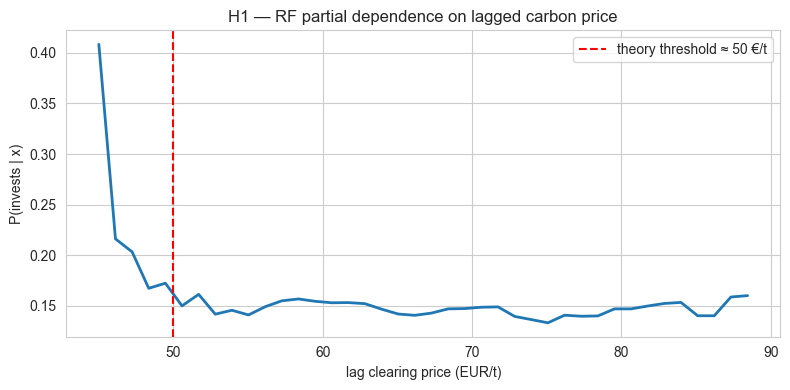

In [24]:
# --- (c) H1 — does carbon price drive green investment? -------------
INV_THRESH = float(np.nanpercentile(pay['invest_cost'], 75)) if len(pay) else 0.0
print(f'Invest threshold (top-quartile invest_cost): {INV_THRESH:.2f} M€')

H1 = pay.dropna(subset=['lag_clearing_price', 'bank_start']).copy()
H1['invests'] = (H1['invest_cost'] > INV_THRESH).astype(int)
arche_dummies = pd.get_dummies(H1['archetype'], prefix='arch', drop_first=True)
H1_X = pd.concat([H1[['lag_clearing_price', 'bank_start', 'year']], arche_dummies], axis=1)
H1_y = H1['invests']

if H1_y.nunique() < 2 or len(H1_y) < 30:
    print('H1 skipped — insufficient label variation or rows.')
else:
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('lr',    LogisticRegression(penalty='l1', solver='saga', max_iter=2000, C=0.5, random_state=0)),
    ])
    cv_score = cross_val_score(pipe, H1_X, H1_y, cv=StratifiedKFold(n_splits=min(5, H1_y.value_counts().min()), shuffle=True, random_state=0), scoring='roc_auc')
    pipe.fit(H1_X, H1_y)
    coefs = pd.Series(pipe.named_steps['lr'].coef_[0], index=H1_X.columns).sort_values(key=abs, ascending=False)
    print(f'H1 logistic LASSO  —  CV AUC = {cv_score.mean():.3f} ± {cv_score.std():.3f}')
    print('Coefficients (standardised features):')
    display(coefs.to_frame('coef'))

    # Random Forest + partial dependence on lagged clearing price.
    rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=0, n_jobs=-1).fit(H1_X, H1_y)
    fi = pd.Series(rf.feature_importances_, index=H1_X.columns).sort_values(ascending=False)
    print('Random forest feature importances:')
    display(fi.to_frame('importance'))

    pd_res = partial_dependence(rf, H1_X, ['lag_clearing_price'], grid_resolution=40)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(pd_res['grid_values'][0], pd_res['average'][0], lw=2)
    ax.axvline(50, color='red', ls='--', label='theory threshold ≈ 50 €/t')
    ax.set(xlabel='lag clearing price (EUR/t)', ylabel='P(invests | x)',
           title='H1 — RF partial dependence on lagged carbon price')
    ax.legend(); plt.tight_layout(); plt.show()

In [25]:
# --- (d) H2 — heterogeneity: high-fossil agents transition faster ----
agent_panel = (
    pay.groupby(['sweep', 'variant', 'seed', 'agent', 'archetype', 'weighting'])
       .agg(mean_clearing=('clearing_price', 'mean'),
            total_invest=('invest_cost', 'sum'),
            init_coal=('init_coal', 'first'),
            init_gas=('init_gas', 'first'),
            init_onshore=('init_onshore', 'first'),
            init_offshore=('init_offshore', 'first'),
            init_solar=('init_solar', 'first'))
       .reset_index()
)
if len(agent_panel) > 0 and 'total_invest' in agent_panel.columns:
    med = float(agent_panel['total_invest'].median())
    agent_panel['transitions'] = (agent_panel['total_invest'] > med).astype(int)
    arche_d = pd.get_dummies(agent_panel['archetype'], prefix='arch', drop_first=True)
    H2_X = pd.concat([agent_panel[['mean_clearing', 'init_coal', 'init_gas']], arche_d], axis=1)
    H2_y = agent_panel['transitions']
    if H2_y.nunique() < 2 or len(H2_y) < 8:
        print('H2 skipped — insufficient sample size for cross-validated logit.')
    else:
        pipe2 = Pipeline([('scale', StandardScaler()),
                          ('lr',    LogisticRegression(penalty='l1', solver='saga', max_iter=2000, C=0.5, random_state=0))])
        n_splits_h2 = max(2, min(5, int(H2_y.value_counts().min())))
        cv2 = cross_val_score(pipe2, H2_X, H2_y,
                              cv=StratifiedKFold(n_splits=n_splits_h2, shuffle=True, random_state=0),
                              scoring='roc_auc')
        pipe2.fit(H2_X, H2_y)
        coefs2 = pd.Series(pipe2.named_steps['lr'].coef_[0], index=H2_X.columns).sort_values(key=abs, ascending=False)
        print(f'H2 logistic LASSO — CV AUC = {cv2.mean():.3f} ± {cv2.std():.3f}')
        print('Sign of init_coal positive ⇒ higher-fossil agents transition faster (the theory prediction).')
        display(coefs2.to_frame('coef'))
else:
    print('H2 skipped — agent panel empty.')

H2 logistic LASSO — CV AUC = 0.731 ± 0.125
Sign of init_coal positive ⇒ higher-fossil agents transition faster (the theory prediction).


,coef
arch_coal-leaning,0.678085
mean_clearing,-0.146575
arch_transitioner,0.085713
init_coal,0.000000
init_gas,0.000000
arch_green-leader,0.000000


**Interpretation.** A positive lag-clearing-price coefficient
in H1 plus a step-up in the RF partial dependence near the theoretical
50 €/t LCOE crossover supports the *carbon price drives green
investment* claim. A positive `init_coal` coefficient in H2 supports
the *high-fossil agents transition faster* claim. The anchor overlay
provides the credibility floor: if realised prices track the
fundamental, the simulation is producing economically-grounded prices,
which feeds RQ1 too.

---

## §R1 — Regulatory Shifts (claim RQ2.a)

> If the loaded sweeps include non-default variants (LRF / MSR / cap
> changes) we run §S1's clustering on each variant separately and
> project everything into the **default-fitted** §S1 PCA basis to make
> the visual comparison direct. Outcomes are summarised with cross-seed
> boxplots and IQR-based outlier flagging.

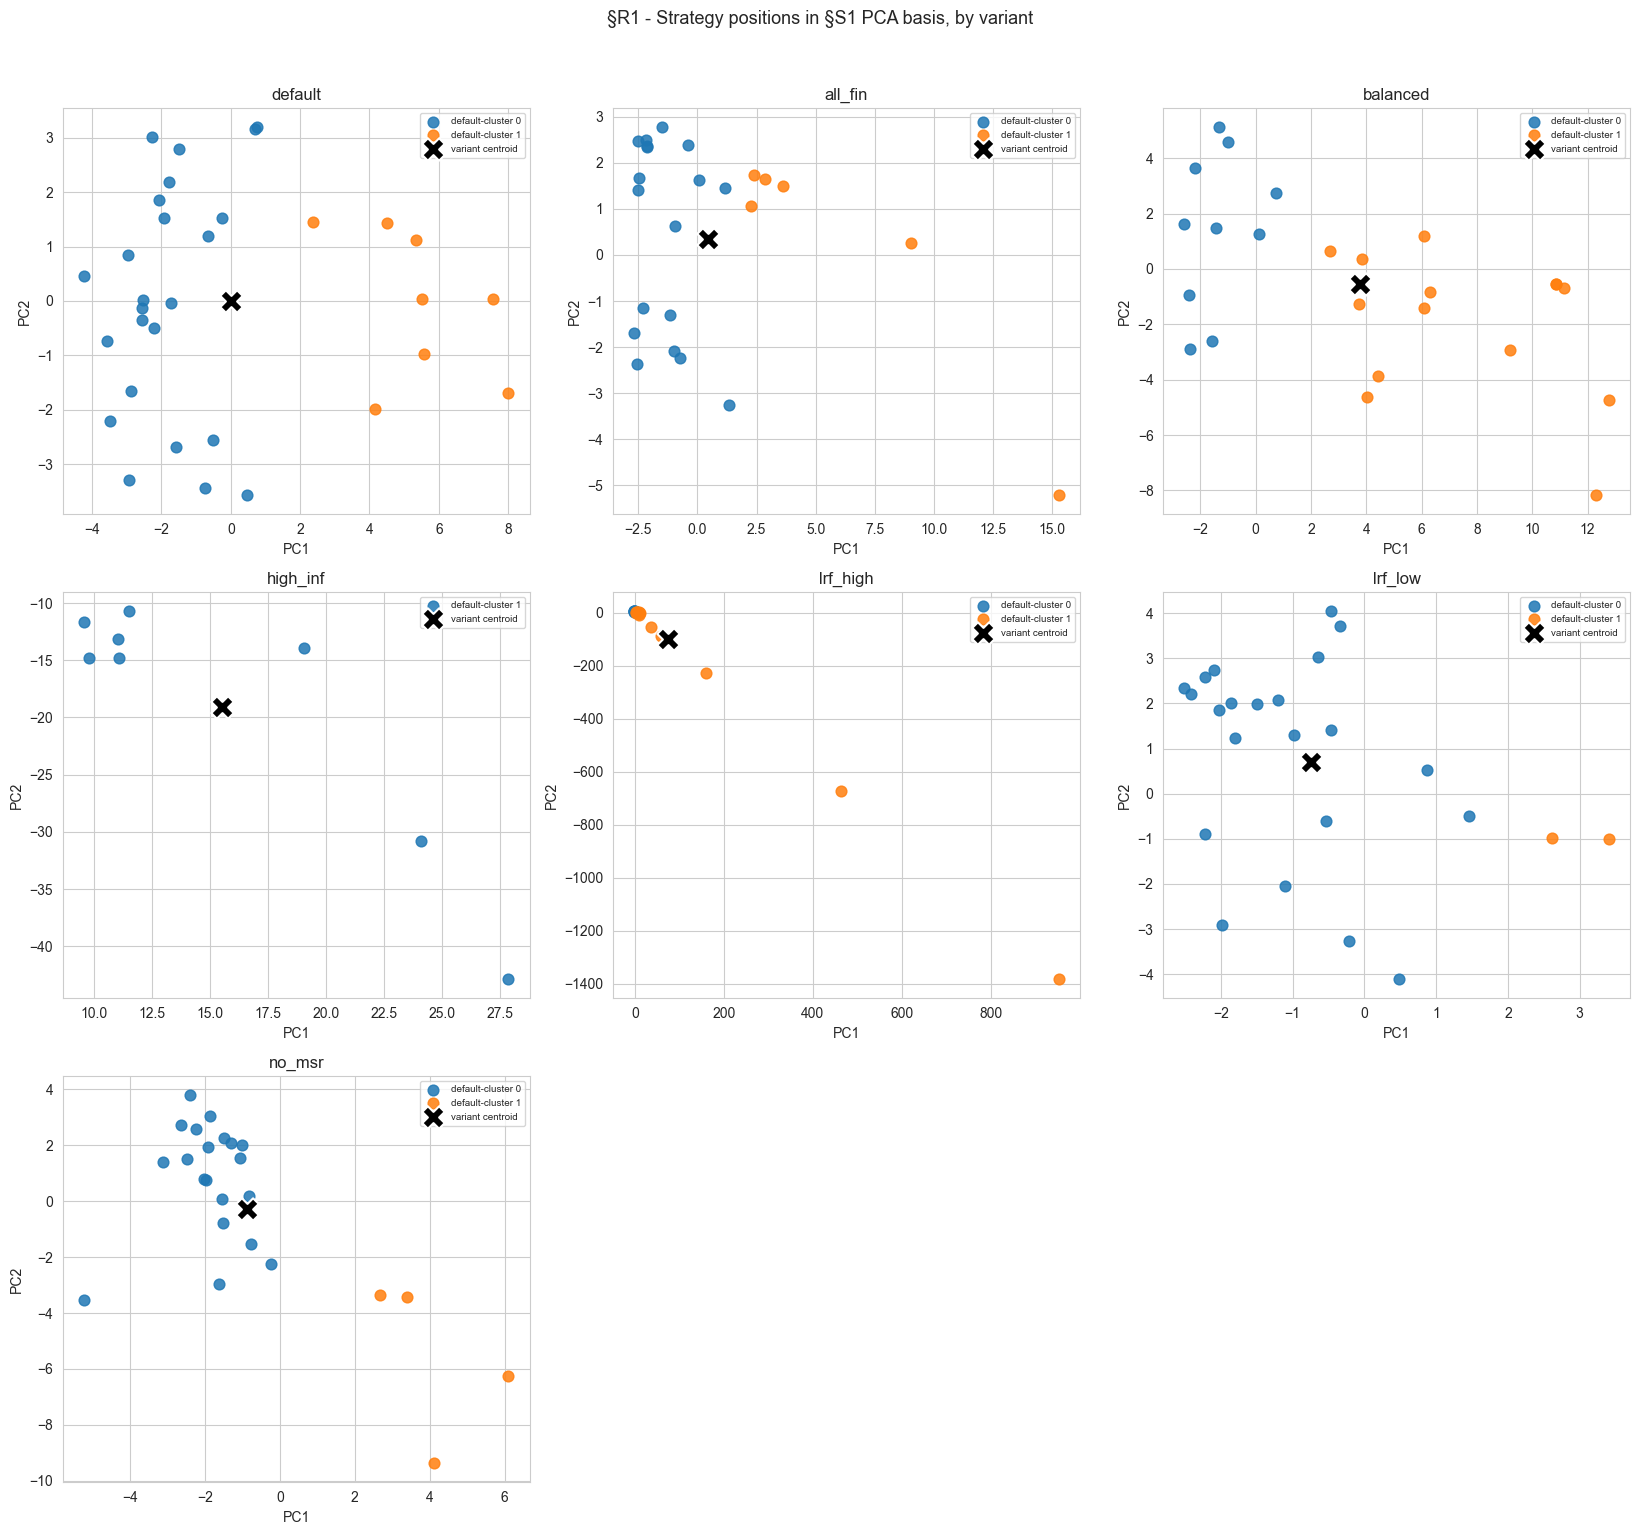

In [26]:
# Filter feat_df by (sweep, variant) and project into the §S1 basis.
variant_keys = sorted({(k[0], k[1]) for k in runs})
variant_keys_overrides = [(s, v) for (s, v) in variant_keys
                          if any(runs[k]['has_overrides'] for k in runs
                                 if k[0] == s and k[1] == v)]

if not variant_keys_overrides:
    print('No override variants loaded - §R1 cluster-shift comparison skipped.')
else:
    n_var = len(variant_keys)
    n_cols = min(n_var, 3); n_rows = int(np.ceil(n_var / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5 * n_rows), squeeze=False)
    for ax_idx, (sw, vn) in enumerate(variant_keys):
        ax = axes[ax_idx // n_cols, ax_idx % n_cols]
        sub = feat_df[(feat_df['sweep'] == sw) & (feat_df['variant'] == vn)]
        if sub.empty:
            ax.set_axis_off(); continue
        v_X = sub[feats].values.astype(float)
        col_means = np.nanmean(v_X, axis=0)
        nan_mask = ~np.isfinite(v_X)
        v_X[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
        v_X_std = scaler.transform(v_X)
        v_P = pca.transform(v_X_std)
        labels_pred = km.predict(v_X_std)
        for c in np.unique(labels_pred):
            sel = labels_pred == c
            ax.scatter(v_P[sel, 0], v_P[sel, 1], s=60, alpha=0.85,
                       label=f'default-cluster {c}')
        ax.scatter(v_P[:, 0].mean(), v_P[:, 1].mean(), marker='X', s=260, color='k',
                   edgecolor='white', linewidth=1.5, label='variant centroid')
        ax.set(title=f'{vn}', xlabel='PC1', ylabel='PC2')
        ax.legend(fontsize=7)
    for ax_idx in range(len(variant_keys), n_rows * n_cols):
        axes[ax_idx // n_cols, ax_idx % n_cols].set_axis_off()
    plt.suptitle('§R1 - Strategy positions in §S1 PCA basis, by variant', y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()


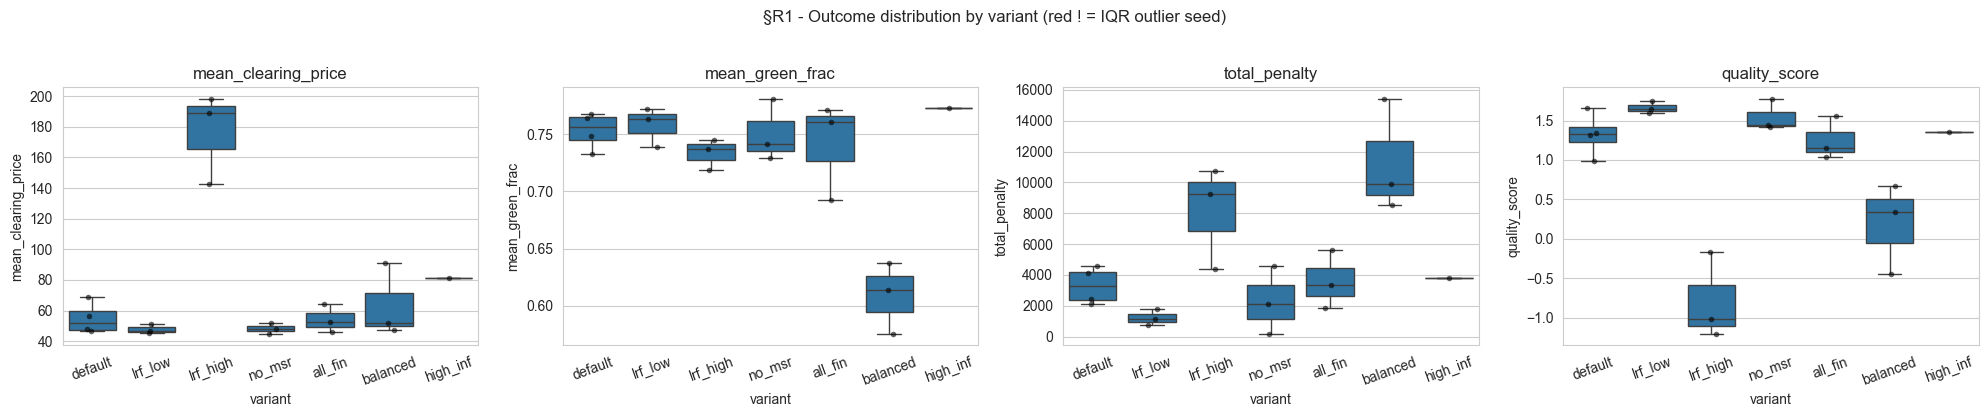

mean_clearing_price                  mean_green_frac                 total_penalty                    quality_score                
                        mean        std count            mean       std count          mean          std count          mean       std count
variant                                                                                                                                     
all_fin            54.271867   9.275095     3        0.741434  0.042773     3   3601.810303  1888.703418     3      1.250820  0.277148     3
balanced           63.445243  24.029583     3        0.609126  0.031296     3  11267.906250  3640.908113     3      0.191500  0.574242     3
default            54.861271  10.340213     4        0.753379  0.016073     4   3310.676819  1202.726576     4      1.326705  0.275635     4
high_inf           81.543251        NaN     1        0.772743       NaN     1   3797.364014          NaN     1      1.350620       NaN     1
lrf_high          176.480977  29.909300     3        0.733499  0.013589     3   8133.390299  3325.457176     3     -0.794253  0.552371     3
lrf_low            47.937894   3.100189     3        0.758230  0.017635     3   1240.744344   517.737453     3      1.661887  0.081775     3
no_msr             48.132291   3.292752     3        0.750652  0.026639     3   2282.278259  2191.733399     3      1.541780  0.199128     3

In [27]:
# Outcome boxplots from cached `out_df` (built in pre-compute).
OUT_METRICS = ['mean_clearing_price', 'mean_green_frac', 'total_penalty', 'quality_score']
OUT_METRICS = [m for m in OUT_METRICS if m in out_df.columns]

fig, axes = plt.subplots(1, len(OUT_METRICS), figsize=(5 * len(OUT_METRICS), 4))
if len(OUT_METRICS) == 1:
    axes = [axes]
for ax, name in zip(axes, OUT_METRICS):
    sns.boxplot(data=out_df, x='variant', y=name, ax=ax, showfliers=False)
    sns.stripplot(data=out_df, x='variant', y=name, ax=ax, color='black', size=4, alpha=0.6)
    for v in out_df['variant'].unique():
        sub = out_df[out_df['variant'] == v][name].dropna()
        if len(sub) >= 4:
            q1, q3 = sub.quantile([0.25, 0.75]); iqr = q3 - q1
            mask = (sub < q1 - 1.5 * iqr) | (sub > q3 + 1.5 * iqr)
            for v_idx, value in zip(sub.index[mask], sub[mask]):
                ax.annotate('!', xy=(list(out_df['variant'].unique()).index(v), value),
                            color='red', fontsize=12, ha='center')
    ax.set_title(name); ax.tick_params(axis='x', rotation=20)
plt.suptitle('§R1 - Outcome distribution by variant (red ! = IQR outlier seed)', y=1.03)
plt.tight_layout(); plt.show()
display(out_df.drop(columns=['sweep', 'seed']).groupby('variant').agg(['mean', 'std', 'count']))


---

### §R1.b — Cross-variant outcome statistics

For each loaded override variant we compute the per-seed mean of the
headline outcomes, the percentage change vs. the default-config mean, and
Cohen's *d* against the default seeds. With ~3 seeds per variant these are
descriptive (no formal hypothesis test) but they make the regulatory
channel explicit: which outcome moves the most under each variant?


In [28]:
# Cross-variant outcome statistics. Rebuilt from `out_df` (cell §R1) so we
# stay consistent with the boxplot panel above.
if 'out_df' in dir() and not out_df.empty:
    metrics_present = [m for m in ['mean_clearing_price', 'mean_green_frac',
                                    'total_penalty', 'quality_score']
                        if m in out_df.columns]
    default_mask = out_df['variant'] == 'default'
    if not default_mask.any():
        print('§R1.b — `default` variant not loaded; skipping cross-variant stats.')
    else:
        ref = out_df[default_mask][metrics_present]
        ref_mu = ref.mean(); ref_sd = ref.std(ddof=1)

        rows = []
        for v in sorted(out_df['variant'].unique()):
            sub = out_df[out_df['variant'] == v][metrics_present]
            if sub.empty:
                continue
            for m in metrics_present:
                v_mu = float(sub[m].mean())
                v_sd = float(sub[m].std(ddof=1)) if len(sub) > 1 else float('nan')
                d_mu = float(ref_mu[m])
                # Pooled SD for Cohen's d (treat unequal sample sizes safely).
                pooled = float(np.sqrt(((len(sub) - 1) * (v_sd or 0) ** 2 +
                                        (len(ref) - 1) * (ref_sd[m] or 0) ** 2) /
                                       max(1, len(sub) + len(ref) - 2))) if len(ref) + len(sub) > 2 else float('nan')
                d_eff = (v_mu - d_mu) / pooled if (pooled and np.isfinite(pooled) and pooled > 1e-12) else float('nan')
                pct = 100.0 * (v_mu - d_mu) / d_mu if abs(d_mu) > 1e-9 else float('nan')
                rows.append({'variant': v, 'metric': m, 'n_seeds': int(len(sub)),
                             'mean': v_mu, 'std': v_sd, 'Δ vs default (%)': pct,
                             "Cohen's d": d_eff})
        rq2_stats = pd.DataFrame(rows)
        print('§R1.b — Per-variant outcome stats (vs. default reference):')
        display(rq2_stats.style.format({'mean': '{:.4g}', 'std': '{:.3g}',
                                        'Δ vs default (%)': '{:+.1f}',
                                        "Cohen's d": '{:+.2f}'}))

        # Identify the dominant regulatory channel per non-default variant.
        non_def = rq2_stats[rq2_stats['variant'] != 'default'].dropna(subset=["Cohen's d"])
        if not non_def.empty:
            dominant = (non_def.assign(_abs_d=non_def["Cohen's d"].abs())
                                .sort_values('_abs_d', ascending=False)
                                .groupby('variant')
                                .head(1)
                                .drop(columns='_abs_d'))
            print('§R1.b — Largest-effect channel per variant '
                  '(largest |Cohen\'s d| against default):')
            display(dominant.style.format({'mean': '{:.4g}', 'std': '{:.3g}',
                                            'Δ vs default (%)': '{:+.1f}',
                                            "Cohen's d": '{:+.2f}'}))
else:
    print('§R1.b skipped — outcome frame `out_df` not built.')


§R1.b — Per-variant outcome stats (vs. default reference):


,variant,metric,n_seeds,mean,std,Δ vs default (%),Cohen's d
0,all_fin,mean_clearing_price,3,54.27,9.28,-1.1,-0.06
1,all_fin,mean_green_frac,3,0.7414,0.0428,-1.6,-0.40
2,all_fin,total_penalty,3,3602,1.89e+03,+8.8,+0.19
3,all_fin,quality_score,3,1.251,0.277,-5.7,-0.27
4,balanced,mean_clearing_price,3,63.45,24,+15.6,+0.50
5,balanced,mean_green_frac,3,0.6091,0.0313,-19.1,-6.17
6,balanced,total_penalty,3,1.127e+04,3.64e+03,+240.4,+3.20
7,balanced,quality_score,3,0.1915,0.574,-85.6,-2.69
8,default,mean_clearing_price,4,54.86,10.3,+0.0,+0.00
9,default,mean_green_frac,4,0.7534,0.0161,+0.0,+0.00


§R1.b — Largest-effect channel per variant (largest |Cohen's d| against default):


,variant,metric,n_seeds,mean,std,Δ vs default (%),Cohen's d
5,balanced,mean_green_frac,3,0.6091,0.0313,-19.1,-6.17
16,lrf_high,mean_clearing_price,3,176.5,29.9,+221.7,+5.92
22,lrf_low,total_penalty,3,1241,518,-62.5,-2.10
27,no_msr,quality_score,3,1.542,0.199,+16.2,+0.87
1,all_fin,mean_green_frac,3,0.7414,0.0428,-1.6,-0.40


---

### §R1.c — Inflation-stress anchor check (`high_inf` variant)

The thesis sweep includes a single-seed `high_inf` cell with elevated
penalty inflation drift (4 % vs. 2 % default) and ~1.5× the inflation
variance. Two design components are sensitive to inflation:

* The **inflation-aware MA3 budget gate** uses `MA3 × infl(t)/infl(t-1)`
  so the price floor adapts to drift; a runaway clearing price under
  high inflation would mean the gate is failing.
* The **real-anchor ESG flow term** uses `anchor_real_t / anchor_real_0`,
  i.e. drift is divided out by construction.

We re-run §S3's anchor-credibility check restricted to `high_inf` and
report the same correlation / MAD numbers as a stress sanity check.


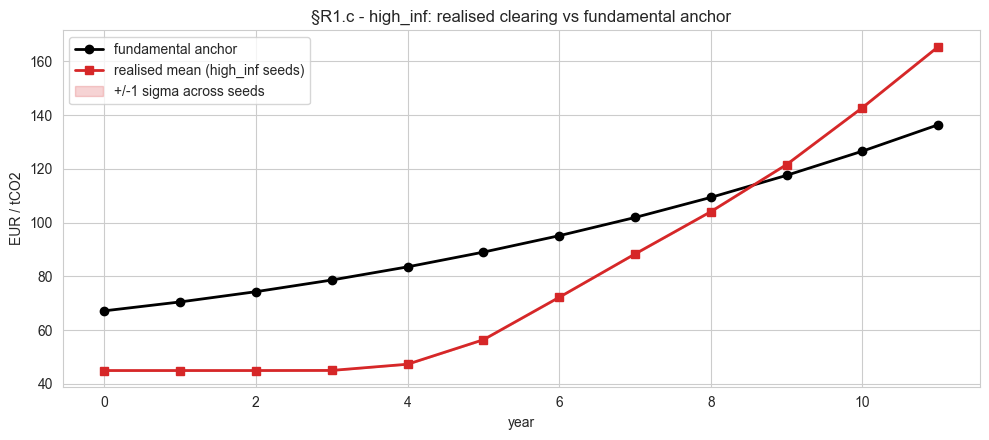

high_inf - Pearson correlation (realised, anchor): +0.978
high_inf - Mean absolute deviation: 22.55 EUR/t
Read: tracking should be comparable to the default-config anchor check because the anchor is computed in real EUR by construction. A large gap indicates the inflation-aware budget gate is binding.


In [29]:
# high_inf inflation-stress anchor check from cached clearing_per_year_df.
inf_keys = [k for k, v in runs.items() if 'high_inf' in v['variant']]
if not inf_keys:
    print('§R1.c - `high_inf` variant not loaded; inflation-stress check skipped.')
else:
    inf_df = clearing_per_year_df[
        clearing_per_year_df.set_index(['sweep', 'variant', 'seed']).index.isin(inf_keys)
    ].copy()
    if inf_df.empty or inf_df['clearing'].dropna().empty:
        print('§R1.c - high_inf rows lack clearing-price data - skipping.')
    else:
        panel_inf = (inf_df.groupby('year')
                            .agg(realised_mean=('clearing', 'mean'),
                                 realised_std =('clearing', 'std'),
                                 anchor=('anchor', 'mean'))
                            .reset_index())
        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.plot(panel_inf['year'], panel_inf['anchor'],        '-o', color='black', lw=2, label='fundamental anchor')
        ax.plot(panel_inf['year'], panel_inf['realised_mean'], '-s', color='C3',    lw=2, label='realised mean (high_inf seeds)')
        ax.fill_between(panel_inf['year'],
                        panel_inf['realised_mean'] - panel_inf['realised_std'].fillna(0),
                        panel_inf['realised_mean'] + panel_inf['realised_std'].fillna(0),
                        alpha=0.20, color='C3', label='+/-1 sigma across seeds')
        ax.set(xlabel='year', ylabel='EUR / tCO2',
               title='§R1.c - high_inf: realised clearing vs fundamental anchor')
        ax.legend(); plt.tight_layout(); plt.show()

        valid = panel_inf.dropna(subset=['realised_mean', 'anchor'])
        if len(valid) > 1:
            corr = float(np.corrcoef(valid['realised_mean'], valid['anchor'])[0, 1])
            mad  = float(np.mean(np.abs(valid['realised_mean'] - valid['anchor'])))
            print(f'high_inf - Pearson correlation (realised, anchor): {corr:+.3f}')
            print(f'high_inf - Mean absolute deviation: {mad:.2f} EUR/t')
            print('Read: tracking should be comparable to the default-config anchor check '
                  'because the anchor is computed in real EUR by construction. '
                  'A large gap indicates the inflation-aware budget gate is binding.')


---

## §R2 — UDBC Compliance Pathways (claim RQ2.b)

The simulator already classifies each `(agent, year)` cell into one of
five buckets — **U** (under-allocation), **D** (debt-cascade),
**M** (mixed), **B** (bought-into-compliance), **C** (compliant). We
exploit this directly:

* **Multinomial logistic regression** predicting the bucket from
  `bank_start`, `cap`, `clearing_price`, archetype, `year`, variant,
  plus the per-cell incompliance diagnostics carried by the augmented
  UDBC panel (`cf_start`, `bid_price`, `bid_qty_mult`,
  `bid_to_clearing`, `oversubscription_ratio`, `coverage_gap`).
  **Random Forest** as the non-linear robustness check; its feature
  importances surface the most discriminative incompliance signals.
* **Class imbalance:** C dominates → fit with and without **SMOTE**
  oversampling and report the comparison.
* **Transition heatmaps** of year-t → year-t+1 bucket transitions per
  variant.

Per-cell labels live in `udbc_*_total_A{i}` only as *episode totals*,
so we proxy the per-(agent, year) bucket by combining year-log
shortfall and the episode-level bucket totals: a year is `B` if the
agent traded volume on the secondary > 0 and `shortfall ≈ 0`, `C` if
shortfall ≈ 0 and no buying, `U` otherwise (alloc<emiss, no
inherited cf), `D` if there is positive carry-forward, `M` otherwise.

In [30]:
# UDBC panel was built during the streaming pre-compute.
print(f'UDBC panel: {len(udbc_df)} (run, agent, year) cells')
if not udbc_df.empty:
    print('Class distribution:')
    print(udbc_df['label'].value_counts())


UDBC panel: 31995648 (run, agent, year) cells
Class distribution:
label
C    19953068
B     6211147
U     3173605
M     2657828
Name: count, dtype: int64


In [31]:
# --- Multinomial logit with / without SMOTE --------------------------
# On the production sweep this panel can hit tens of millions of rows. Cap
# the fit set with a stratified subsample (`R2_FIT_CAP`); the test set is
# also drawn from that stratified pool so the classification report stays
# representative of the converged-window distribution.
R2_FIT_CAP = 200_000

if udbc_df.empty or udbc_df['label'].nunique() < 2:
    print('UDBC modelling skipped — insufficient label variety.')
else:
    # Augmented feature set: raw market state + per-cell incompliance
    # diagnostics (oversubscription, bid-to-clearing, inherited debt at start
    # of year, bid-quantity multiplier, coverage gap). Each is silently
    # dropped if absent on older logs.
    feat_cols_all = ['cap', 'clearing_price', 'bank_start', 'year',
                     'cf_start', 'bid_price', 'bid_qty_mult',
                     'bid_to_clearing', 'oversubscription_ratio',
                     'coverage_gap']
    feat_cols = [c for c in feat_cols_all if c in udbc_df.columns]
    cat_cols  = ['archetype', 'weighting', 'variant']
    df_m = udbc_df.dropna(subset=feat_cols + ['label']).copy()

    if len(df_m) > R2_FIT_CAP:
        # Stratified subsample preserves rare classes (esp. U/D/M).
        # Build per-class caps explicitly to avoid the pandas
        # DeprecationWarning around .apply on grouped frames.
        n_total = len(df_m)
        caps = {lab: max(50, R2_FIT_CAP * cnt // n_total)
                for lab, cnt in df_m['label'].value_counts().items()}
        keep_idx = []
        for lab, sub in df_m.groupby('label'):
            n = min(len(sub), caps[lab])
            keep_idx.extend(sub.sample(n=n, random_state=0).index)
        df_m = df_m.loc[keep_idx].reset_index(drop=True)
        print(f'§R2 — subsampled fit set to {len(df_m)} rows (cap={R2_FIT_CAP}).')

    Xm = pd.concat([df_m[feat_cols].astype(float),
                    pd.get_dummies(df_m[cat_cols], drop_first=True)], axis=1)
    ym = df_m['label'].values

    Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.25, random_state=0, stratify=ym)
    pipe = Pipeline([('sc', StandardScaler(with_mean=False)),
                     ('lr', LogisticRegression(max_iter=2000, solver='lbfgs', random_state=0, n_jobs=-1))])
    pipe.fit(Xtr, ytr)
    print('Multinomial logit (no SMOTE)  —  test classification report:')
    print(classification_report(yte, pipe.predict(Xte)))

    if _HAS_SMOTE and pd.Series(ytr).value_counts().min() >= 6:
        try:
            from imblearn.pipeline import Pipeline as ImbPipe
            sm_pipe = ImbPipe([('sc', StandardScaler(with_mean=False)),
                               ('sm', SMOTE(random_state=0, k_neighbors=3)),
                               ('lr', LogisticRegression(max_iter=2000, solver='lbfgs', random_state=0, n_jobs=-1))])
            sm_pipe.fit(Xtr, ytr)
            print('Multinomial logit (with SMOTE) — test classification report:')
            print(classification_report(yte, sm_pipe.predict(Xte)))
        except Exception as e:
            print(f'SMOTE step skipped: {e}')
    else:
        print('SMOTE skipped — not enough samples in the minority classes for k-neighbours.')

    # Random Forest robustness + feature importances.
    rfm = RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1).fit(Xtr, ytr)
    print('Random forest — test classification report:')
    print(classification_report(yte, rfm.predict(Xte)))
    fi = pd.Series(rfm.feature_importances_, index=Xm.columns).sort_values(ascending=False).head(10)
    display(fi.to_frame('importance'))


§R2 — subsampled fit set to 199997 rows (cap=200000).
Multinomial logit (no SMOTE)  —  test classification report:
              precision    recall  f1-score   support

           B       0.62      0.27      0.38      9706
           C       0.77      0.93      0.84     31181
           M       0.83      0.42      0.56      4153
           U       0.78      0.92      0.85      4960

    accuracy                           0.76     50000
   macro avg       0.75      0.64      0.66     50000
weighted avg       0.74      0.76      0.73     50000

Multinomial logit (with SMOTE) — test classification report:
              precision    recall  f1-score   support

           B       0.42      0.80      0.55      9706
           C       0.89      0.54      0.67     31181
           M       0.51      0.77      0.61      4153
           U       0.75      0.95      0.84      4960

    accuracy                           0.65     50000
   macro avg       0.64      0.76      0.67     50000
weighted 

,importance
bank_start,0.194683
coverage_gap,0.188146
oversubscription_ratio,0.106853
bid_qty_mult,0.088440
cf_start,0.083398
bid_price,0.062851
bid_to_clearing,0.058340
cap,0.038985
year,0.036332
clearing_price,0.030263


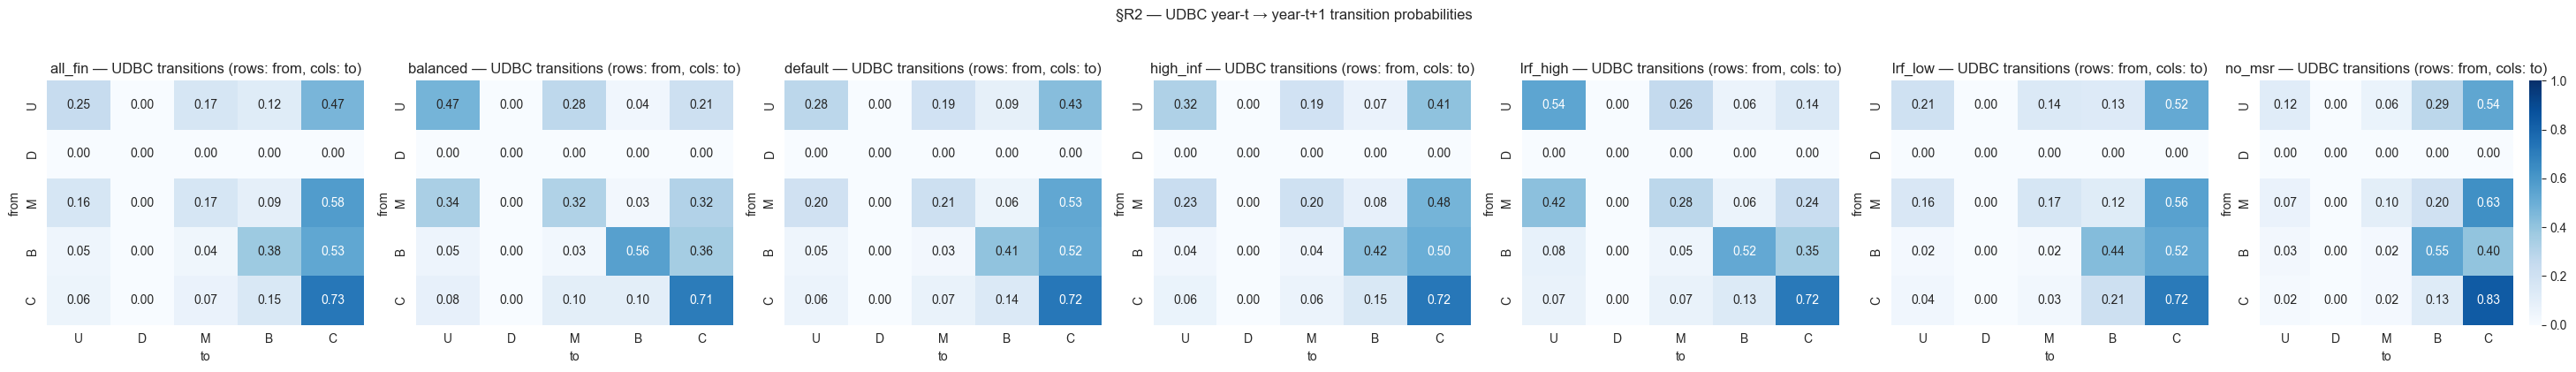

In [32]:
# --- Transition heatmaps year-t → year-t+1 per variant --------------
def _transition_matrix(df_var):
    pairs = []
    for (variant, seed, agent), grp in df_var.groupby(['variant', 'seed', 'agent']):
        grp_sorted = grp.sort_values('year')
        labs = grp_sorted['label'].values
        for a, b in zip(labs[:-1], labs[1:]):
            pairs.append((a, b))
    if not pairs:
        return pd.DataFrame(0, index=UDBC_BUCKETS, columns=UDBC_BUCKETS)
    df_p = pd.DataFrame(pairs, columns=['from', 'to'])
    M = pd.crosstab(df_p['from'], df_p['to'])
    M = M.reindex(index=UDBC_BUCKETS, columns=UDBC_BUCKETS, fill_value=0)
    return M.div(M.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)


variants_present = sorted(udbc_df['variant'].unique())
n_v = len(variants_present)
fig, axes = plt.subplots(1, n_v, figsize=(4.2 * n_v, 4), squeeze=False)
for ax, v in zip(axes[0], variants_present):
    M = _transition_matrix(udbc_df[udbc_df['variant'] == v])
    sns.heatmap(M, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax,
                cbar=(ax is axes[0, -1]))
    ax.set(title=f'{v} — UDBC transitions (rows: from, cols: to)',
           xlabel='to', ylabel='from')
plt.suptitle('§R2 — UDBC year-t → year-t+1 transition probabilities', y=1.04)
plt.tight_layout(); plt.show()

**Interpretation.** Coefficients on `cap` (negative) and
`clearing_price` (positive) drive the model toward U / D states —
that's the regulatory lever turning the screw. The transition heatmap
diagonals tell us which buckets are *sticky*: tighter LRF should
plausibly raise the U → U probability and lower the U → C recovery
rate. Comparing variants side-by-side answers RQ2.b directly.

---

## Summary — Mapping Panels Back to Claims

| Claim | Section | Panels |
|---|---|---|
| RQ1.a — Agents converge by episode N | §C1 | reward + price trajectory with PELT/plateau cutoff |
| RQ1.b — Findings replicate across seeds | §C2 | fan charts + cross-seed CV table |
| RQ3.a — Distinguishable strategic archetypes | §S1 | elbow/silhouette, dendrogram, PCA, archetype × cluster crosstab |
| RQ3.b — Removing ESG component collapses the strategy space | §S2 | within-default contrast + `all_fin` & `balanced` PCA panels + spread/silhouette table + outcome comparison |
| RQ3.c — Agents respond rationally to incentives | §S3 | anchor overlay, H1 LASSO + RF partial dependence, H2 logit |
| RQ2.a — Regulatory levers shift strategies and outcomes | §R1 + §R1.b | per-variant PCA panels + outcome boxplots + Δ%/Cohen's d table |
| RQ2.a (inflation stress) — real-anchor & MA3 gate hold under elevated inflation | §R1.c | anchor vs. realised clearing on `high_inf`, with correlation / MAD |
| RQ2.b — Stricter regulation changes the *type* of compliance failure | §R2 | multinomial logit (with/without SMOTE) + transition heatmaps |

**Reproducibility.** Every section keys off `(sweep, variant, seed)`
and writes nothing back to disk. Re-run from §1 to refresh.

**Out of scope.** Pathology / autoencoder analyses and the
clearing-price prediction model dropped in v3 of the planning doc are
deliberately not implemented here.

---

## §Export — Headline Metrics Table

Persist a `(sweep, variant, seed) → headline metrics` table to
`results/analysis/headline_metrics.csv`. As the thesis-experiments sweep
adds more variants, this CSV becomes the convenient single-source-of-truth
for cross-experiment comparison plots and tables.


In [33]:
# Cross-run headline export from cached `export_rows`. The streaming
# pre-compute already used the C1 convergence cutoff for tail means, so
# every value here is steady-state by construction.
_export_df = pd.DataFrame(export_rows).sort_values(['sweep', 'variant', 'seed'])
_out_dir = PROJECT_ROOT / 'results' / 'analysis'
_out_dir.mkdir(parents=True, exist_ok=True)
_out_path = _out_dir / 'headline_metrics.csv'
_export_df.to_csv(_out_path, index=False)
print(f'Wrote {len(_export_df)} rows -> {_out_path}')
display(_export_df)


Wrote 20 rows -> C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\analysis\headline_metrics.csv


,sweep,variant,seed,n_episodes,convergence_cutoff,tail_frac,system_reward_mean,quality_score_mean,clearing_price_last_mean,mean_green_frac,mean_penalty,mean_invest_cost
0,default_seeds,default,1729,120000,108216,0.098,18.782152,1.708951,85.088104,0.735864,246.979080,656.619934
3,default_seeds,default,5041,120000,101424,0.155,24.573313,1.015931,48.751980,0.747531,539.161194,640.187195
2,default_seeds,default,6561,120000,102672,0.144,11.152141,1.321459,83.122574,0.770580,483.853699,850.851746
1,default_seeds,default,8191,120000,97632,0.186,30.070095,1.285110,57.542191,0.764066,353.248016,797.144287
13,thesis_experiments,all_fin,1729,120000,99240,0.173,18.047422,1.563283,65.162247,0.771296,272.863983,874.065002
15,thesis_experiments,all_fin,6561,120000,87864,0.268,7.954618,1.048589,90.639946,0.695070,407.017548,247.836853
14,thesis_experiments,all_fin,8191,120000,102744,0.144,33.532124,1.118165,46.451618,0.760464,760.451599,716.197266
16,thesis_experiments,balanced,1729,120000,109416,0.088,-31.980082,0.417608,67.712364,0.616784,1107.556396,367.664215
18,thesis_experiments,balanced,6561,120000,110136,0.082,-65.276375,-0.414106,168.066025,0.578894,1895.668457,25.614996
17,thesis_experiments,balanced,8191,120000,102240,0.148,-20.346766,0.672953,52.571392,0.640320,1064.225342,535.516479
